In [18]:
import os

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy import stats
import os
from matplotlib import colors, ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats
import tqdm

import sys
sys.path.append('../dnsm-experiments-1/')

from netam.common import heavy_chain_shim
from netam.framework import load_crepe
from netam.sequences import translate_sequence, AA_STR_SORTED
from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.koenig_helper import KoenigDataset, plot_variant_comparison
from netam.sequences import (AA_STR_SORTED)


figures_dir = localify("FIGURES_DIR")
os.makedirs("_output", exist_ok=True)

# set mpl font to lato
#plt.rcParams["font.family"] = "Lato"

In [2]:
import warnings
import numpy as np

# Filter out the specific NumPy deprecation warning about __array_wrap__
warnings.filterwarnings("ignore", category=DeprecationWarning, 
                       message="__array_wrap__ must accept context and return_scalar")


In [3]:
heavy_wt = "EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS"

In [4]:
def assign_wt(df, wt_seq, value):
    for idx, aa in enumerate(wt_seq):
        df.loc[aa, idx+1] = value

def df_of_arr(arr):
    return pd.DataFrame(arr, columns=range(1, arr.shape[1] + 1), index=list(AA_STR_SORTED))

In [5]:
# Load DASM model
crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"))
#crepe.model.train()
crepe = heavy_chain_shim(crepe)
[dasm_heavy] = crepe([heavy_wt])
log_dasm_heavy = np.log(dasm_heavy).T
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, heavy_wt, np.nan)

In [6]:
log_dasm_heavy

tensor([[-0.7227, -0.6347, -0.4639,  ..., -1.7577, -0.3251,  0.7484],
        [ 0.2837,  0.0109, -2.4311,  ..., -2.0141, -4.4042, -3.1741],
        [-0.5426, -0.6284, -0.8591,  ..., -4.1694,  0.8741,  0.3483],
        ...,
        [-1.9546,     nan,  0.8395,  ...,     nan, -0.0692,  0.5724],
        [-2.4160, -1.8430, -2.3934,  ..., -3.5998, -2.4099, -0.1343],
        [-2.5593, -0.7266,  0.1817,  ..., -4.7174, -0.9831, -1.0503]])

In [7]:
def zero_centered_cb_min_center_max(df):
    data_min = df.min().min()
    data_max = df.max().max()
    assert data_min < 0 and data_max > 0
    return data_min, 0, data_max

def make_heatmap(df, ax, colorbar_label):
    _ = dms_style_heatmap(
        df, 
        ax=ax, 
        cb_min_center_max=zero_centered_cb_min_center_max(df), 
        plot_aa_order=list("YWFLIVAMKRHDESTNQPGC"),
        colorbar_label=colorbar_label)

EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS


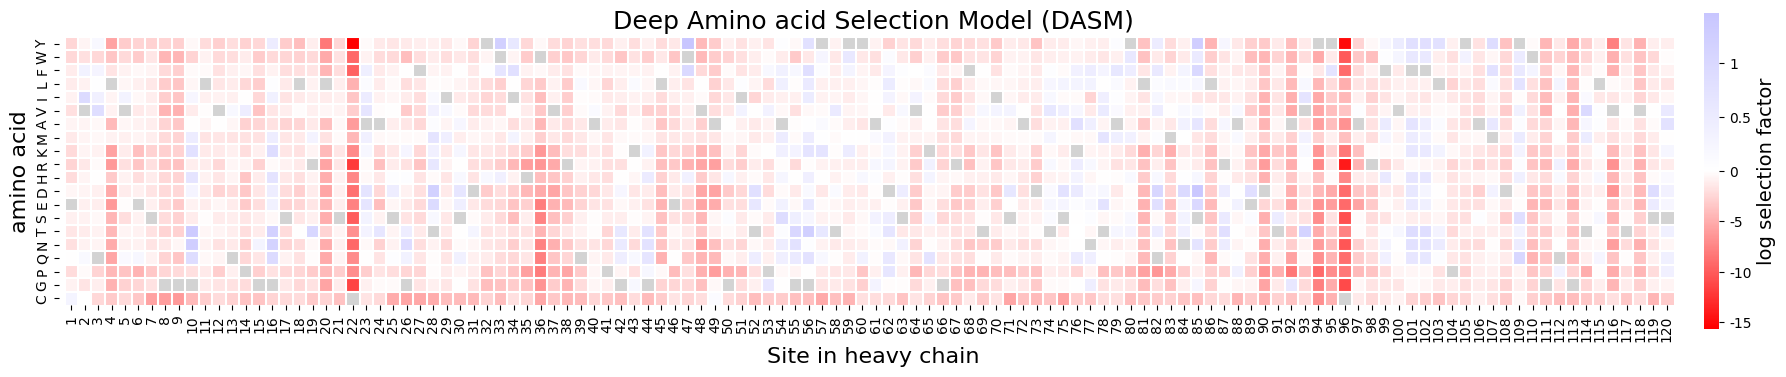

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('Site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()

# Mutate sequence and measure predictions to find epistasis

EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS
EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS


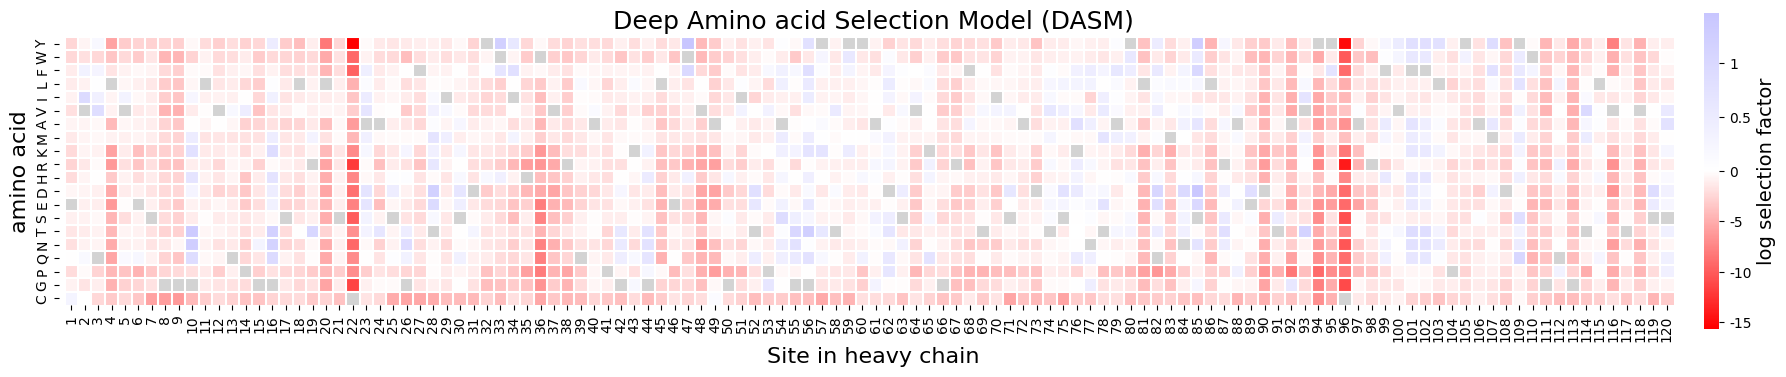

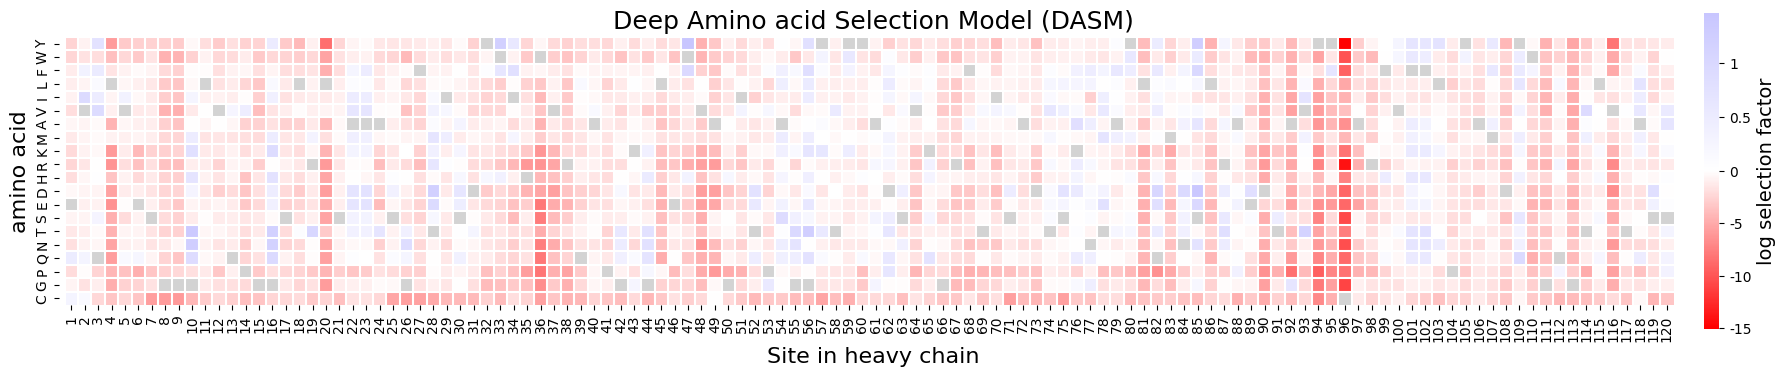

In [9]:
#### Example - two slightly different sequences results in different selection factors


[dasm_heavy] = crepe([heavy_wt])
log_dasm_heavy = np.log(dasm_heavy).T
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, heavy_wt, np.nan)

fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('Site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()



[dasm_heavy] = crepe(['EVQLVESGGGLVQPGGSLRLSAAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTASS'])
log_dasm_heavy = np.log(dasm_heavy).T
log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
assign_wt(log_dasm_heavy_df, 'EVQLVESGGGLVQPGGSLRLSAAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTASS', np.nan)

fig, ax = plt.subplots(1, 1, figsize=(18, 4))

print(heavy_wt)

make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
ax.set_xlabel('Site in heavy chain', fontsize=16)
ax.set_ylabel('amino acid', fontsize=16)
plt.tight_layout()

### Run single mutation analysis

In [40]:
def run_model_mutating_seq(start_seq, device='cpu'):
    crepe = load_crepe(localify("DASM_TRAINED_MODELS_DIR/dasm_4m-v1jaffeCC+v1tangCC-joint"), device=device)
    crepe = heavy_chain_shim(crepe)
    
    # original seq
    [dasm_heavy] = crepe([start_seq])
    log_dasm_heavy = np.log(dasm_heavy).T
    log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
    assign_wt(log_dasm_heavy_df, start_seq, np.nan)
    log_dasm_heavy_df_long = log_dasm_heavy_df.stack().reset_index()
    log_dasm_heavy_df_long.columns = ['AminoAcid', 'Position', 'log_selection_factor']
    original_predictions = log_dasm_heavy_df_long.copy()

    # mutate seq and get predictions
    all_predictions = []

    for pos in tqdm.tqdm(range(1, len(start_seq) + 1)):
        for aa in AA_STR_SORTED:
            seq = start_seq[:pos-1] + aa + start_seq[pos:]
            [dasm_heavy] = crepe([seq])
            log_dasm_heavy = np.log(dasm_heavy).T
            log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
            assign_wt(log_dasm_heavy_df, seq, np.nan)
            log_dasm_heavy_df_long = log_dasm_heavy_df.stack().reset_index()
            log_dasm_heavy_df_long.columns = ['AminoAcid', 'Position', 'log_selection_factor']

            log_dasm_heavy_df_long['mut_from_origin'] = start_seq[pos-1] + str(pos) + aa
        
            all_predictions.append(log_dasm_heavy_df_long)

    # Combine all samples
    all_data = pd.concat(all_predictions, ignore_index=True)

    # add original predictions as comparison
    all_data = pd.merge(all_data, original_predictions, on=['AminoAcid', 'Position'], suffixes=('', '_original'), how='left')

    # add selection factor diff - if + it increased, if - it decreased
    all_data['log_selection_factor_diff'] =  all_data.log_selection_factor - all_data.log_selection_factor_original
    # absulute selection factor diff
    all_data['log_selection_factor_diff_abs'] =  np.abs(all_data['log_selection_factor_diff'])

    # add selection factor ratio - 
    all_data['log_selection_factor_ratio'] =  all_data.log_selection_factor / all_data.log_selection_factor_original 
    # add if there is a flip for diversyfying to purifying and the other way around
    all_data['div_pur_flip'] = (all_data['log_selection_factor'] * all_data['log_selection_factor_original'] < 0)


    return all_data




In [14]:
### plot heatmap of log selection factor differences

ORDERED_INDEX = list("YWFLIVAMKRHDESTNQPGC")

def plot_dasm_heatmap_predictions(seq):
    [dasm_heavy] = crepe([seq])
    log_dasm_heavy = np.log(dasm_heavy).T
    log_dasm_heavy_df = df_of_arr(log_dasm_heavy)
    assign_wt(log_dasm_heavy_df, seq, np.nan)
    fig, ax = plt.subplots(1, 1, figsize=(18, 4))
    make_heatmap(log_dasm_heavy_df, ax, "log selection factor")
    ax.set_title('Deep Amino acid Selection Model (DASM)', fontsize=18)
    ax.set_xlabel('Site in heavy chain', fontsize=16)
    ax.set_ylabel('amino acid', fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_log_heatmap_epistasis(all_data, mutation, measure_to_plot,title='log_selection_factor_diff', original_seq=False, vmin=-1.5, vmax=1.5):
    if original_seq:
        plot_dasm_heatmap_predictions(original_seq)
        plot_dasm_heatmap_predictions(original_seq[:int(mutation[1:-1])-1] + mutation[-1] + original_seq[int(mutation[1:-1]):])   
    
    f, ax = plt.subplots(figsize=(20, 4)) 
    cur_data = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position != int(mutation[1:-1]))].copy()
    cur_data_np = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position == int(mutation[1:-1]))].copy()
    cur_data_np['log_selection_factor_diff'] = np.nan
    cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)
    cur_data = cur_data.pivot(index='AminoAcid', columns='Position', values=measure_to_plot)
    cur_data = cur_data.reindex(ORDERED_INDEX)

    # Set vmin and vmax symmetrically for the coolwarm colormap
    p = sns.heatmap(cur_data, cmap='coolwarm', ax=ax, xticklabels=True, yticklabels=True, 
                   cbar=True, center=0, vmin=vmin, vmax=vmax, linecolor='white', linewidths=0.5)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Site in heavy chain", fontsize=16)
    ax.set_ylabel("Amino acid", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_scatter_epistasis(all_data, mutation):
    # Filter data
    cur_data = all_data[(all_data.mut_from_origin == mutation) & (all_data.Position != int(mutation[1:-1]))].copy()
    
    # Create figure
    plt.figure(figsize=(6, 4))
    
    # Create scatter plot with better styling
    plt.scatter(data=cur_data[cur_data['div_pur_flip'] == False], x = 'log_selection_factor_original', y= 'log_selection_factor', alpha=0.7, s=50, c='royalblue', edgecolor='white', label='same_sign')
    plt.scatter(data=cur_data[cur_data['div_pur_flip'] == True], x = 'log_selection_factor_original', y='log_selection_factor', alpha=0.7, s=50, c='red', edgecolor='white', label='flip sign')


    # Add identity line
    min_val = min(cur_data['log_selection_factor_original'].min(), cur_data['log_selection_factor'].min())
    max_val = max(cur_data['log_selection_factor_original'].max(), cur_data['log_selection_factor'].max())
    
    # Improve labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f"Mutation: {mutation}", fontsize=14, fontweight='bold')
    
    # Add grid and style improvements
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Optional: Calculate correlation
    corr = cur_data['log_selection_factor_original'].corr(cur_data['log_selection_factor'])
    plt.annotate(f'Correlation: {corr:.3f}', 
                xy=(0.05, 0.95), 
                xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    return plt.gca()

def print_epistatics_measurement_summary(all_data, mut):
    cur_data = all_data[(all_data.mut_from_origin == mut) & (all_data.Position != int(mut[1:-1]))].copy()
    print('Positions showing a flip in selection factor:')
    print(cur_data[cur_data['div_pur_flip'] == True].sort_values('log_selection_factor_diff_abs', ascending=False)[['Position', 'AminoAcid', 'log_selection_factor', 'log_selection_factor_original']].head(n=20))
    print('Positions with the highest sum of absolute predictions diffs')
    print(cur_data.groupby('Position').log_selection_factor_diff_abs.sum().sort_values(ascending=False).head(n=10))



In [37]:
# koenig data
heavy_wt = "EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS"

if not os.path.exists("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/koenig.csv"):
    all_data = run_model_mutating_seq(heavy_wt, device='cuda')
    all_data.to_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/koenig.csv", index=False)

all_data = pd.read_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/koenig.csv")


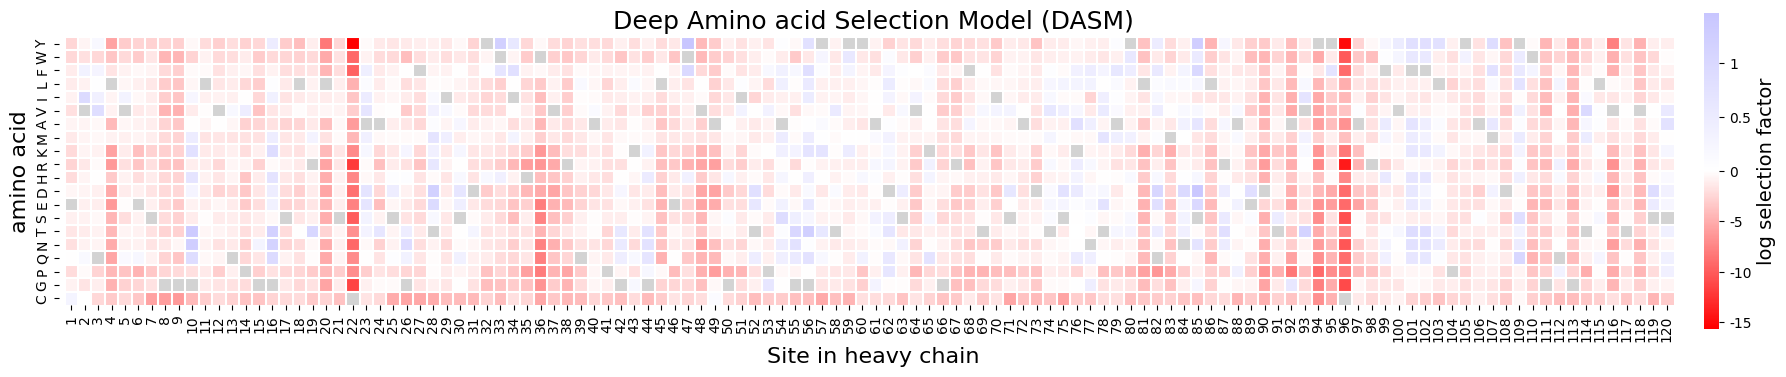

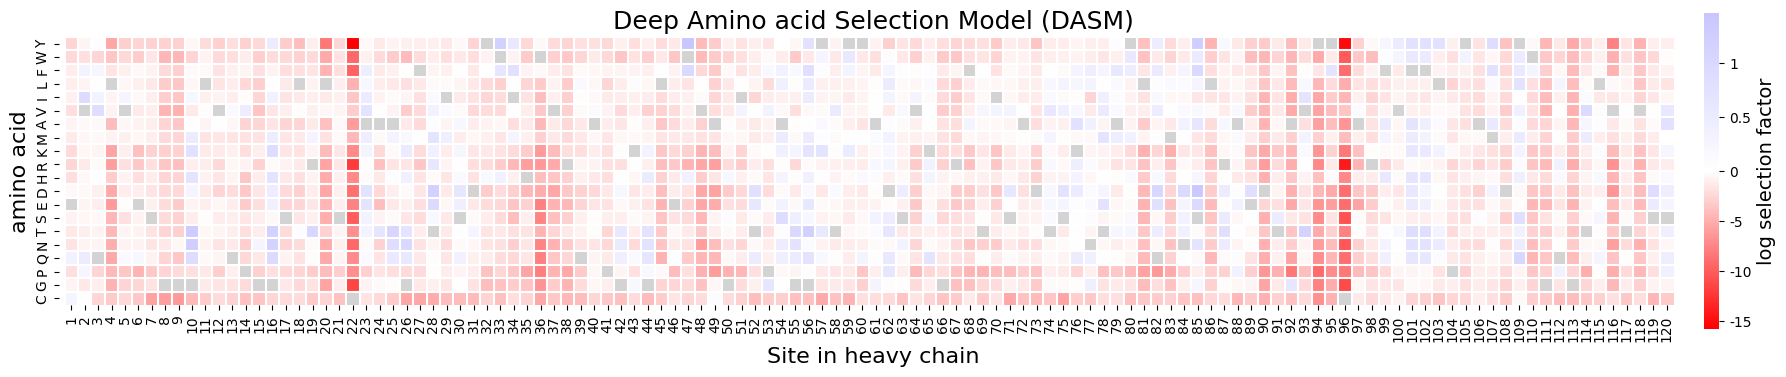

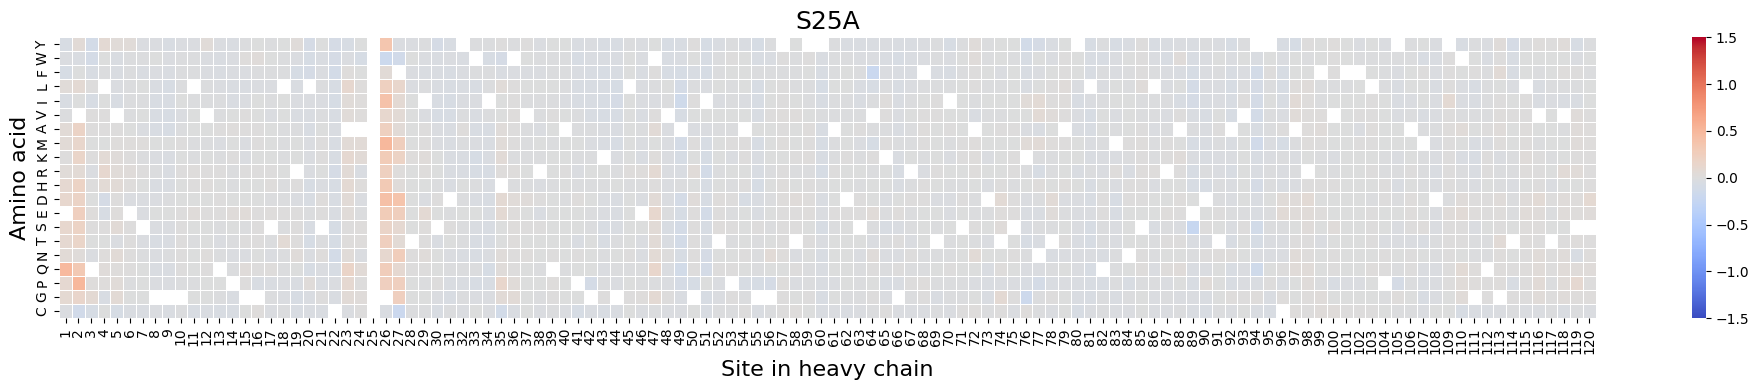

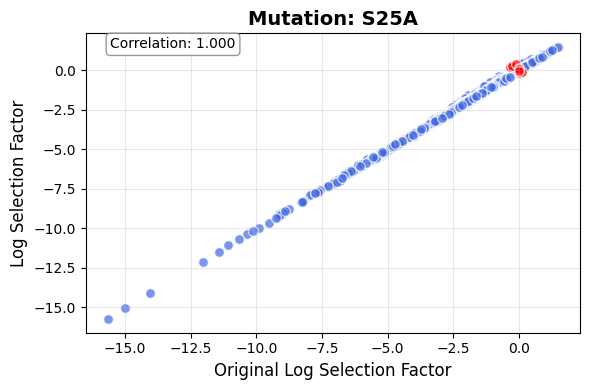

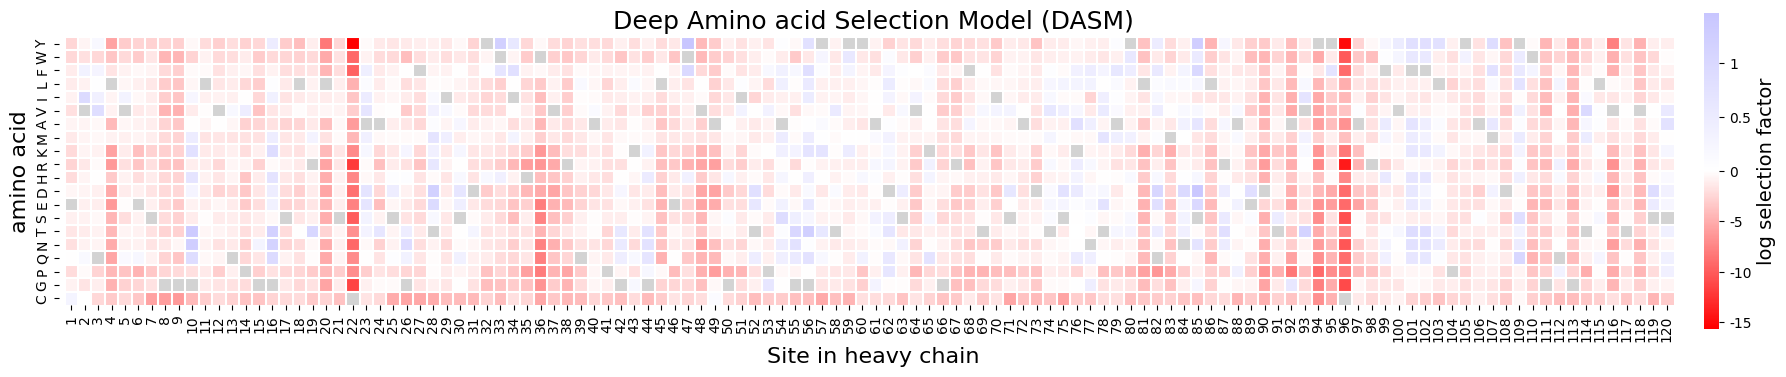

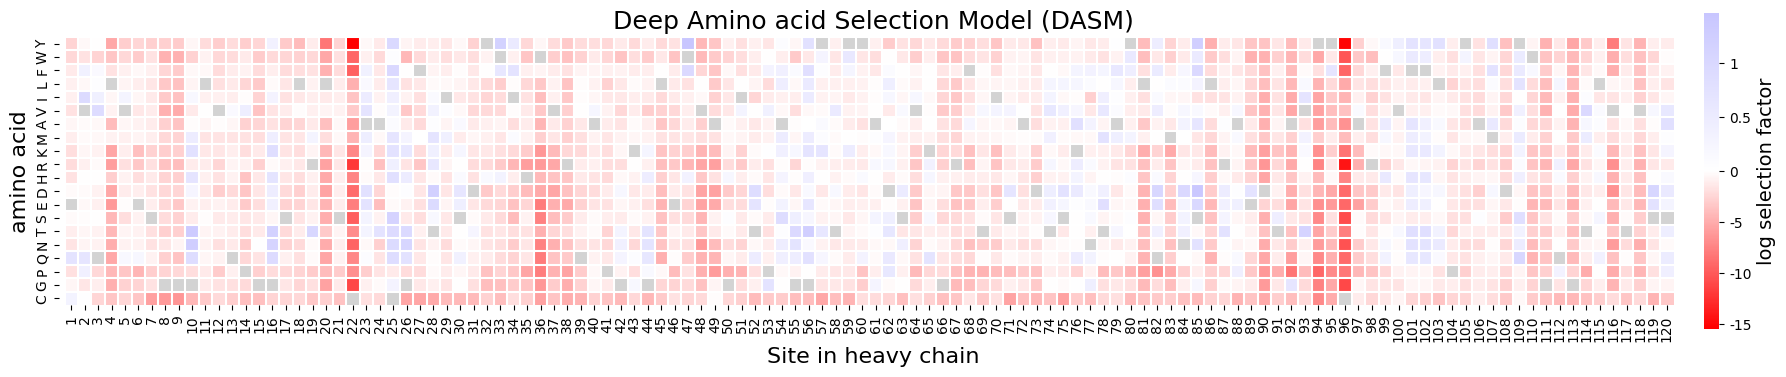

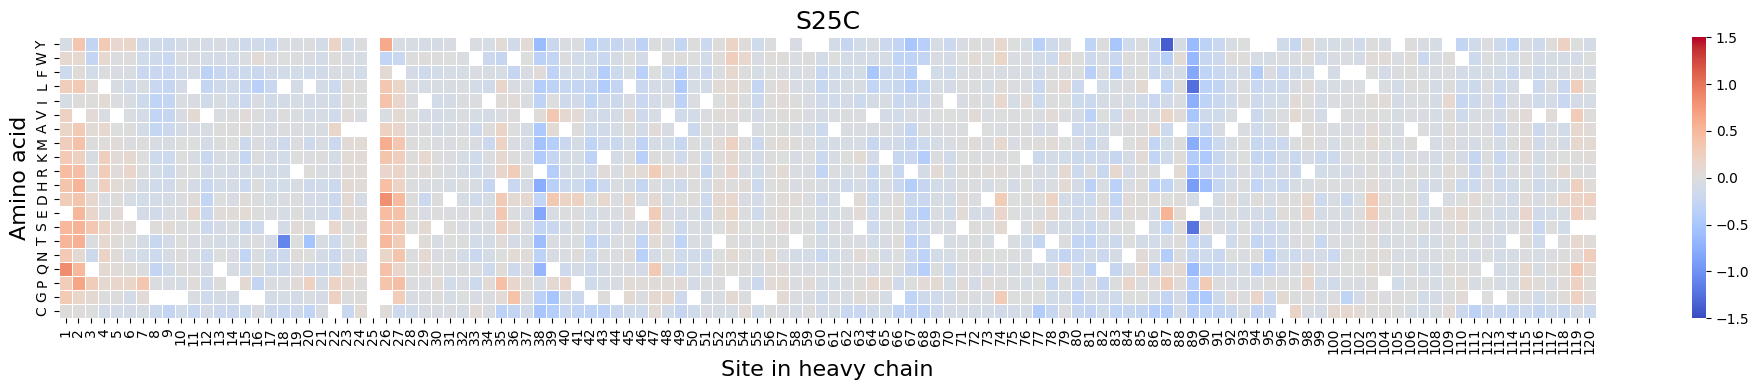

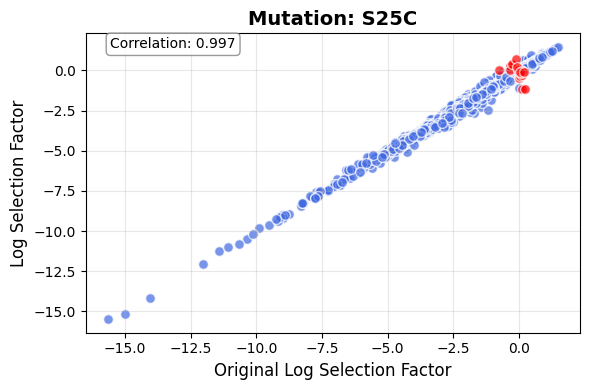

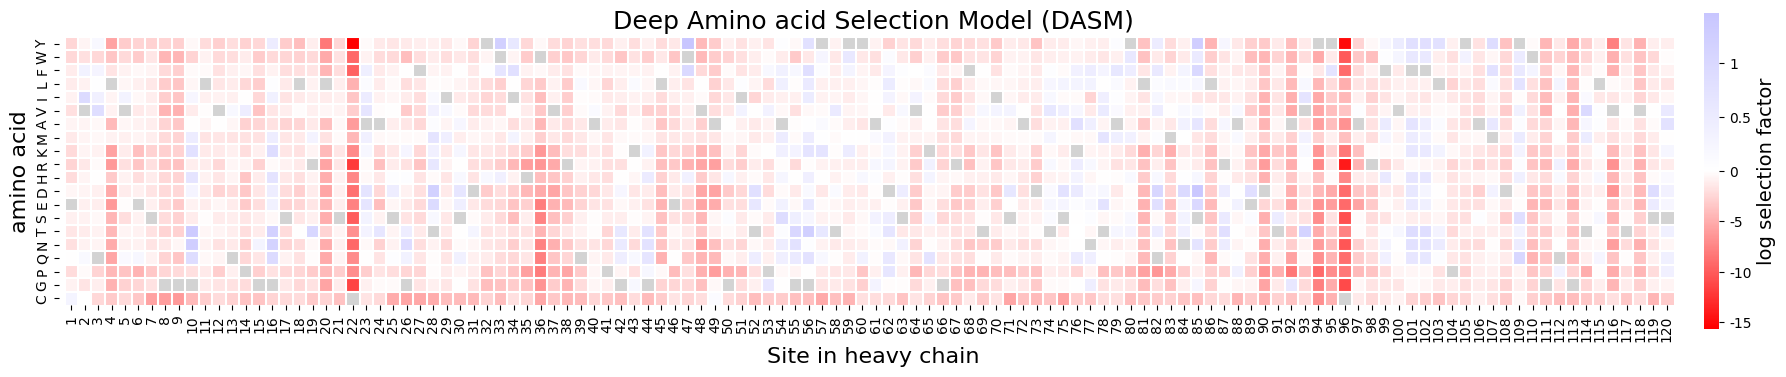

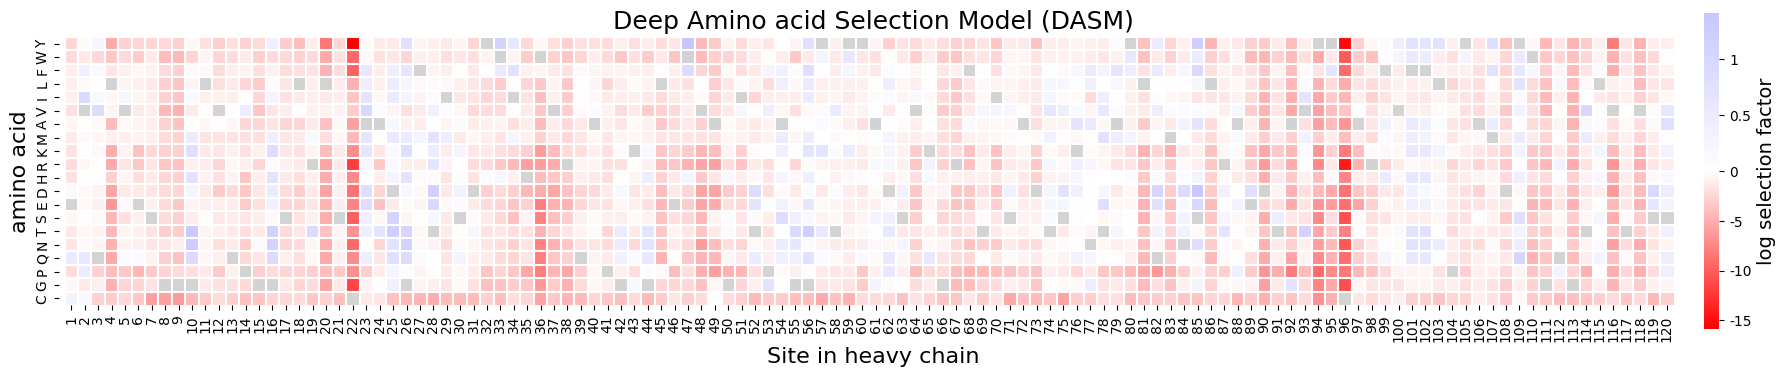

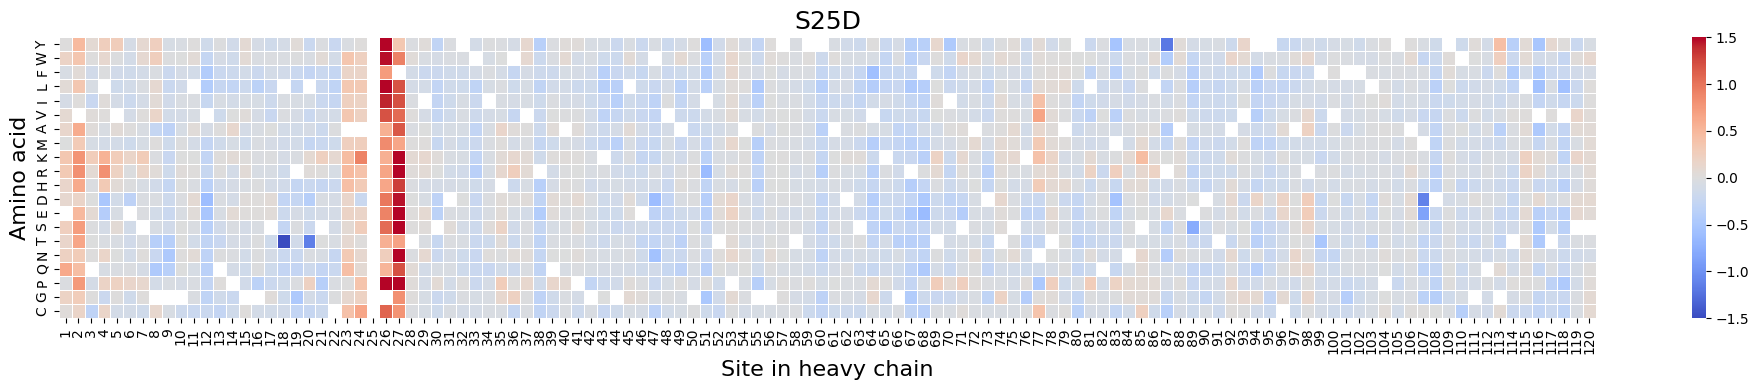

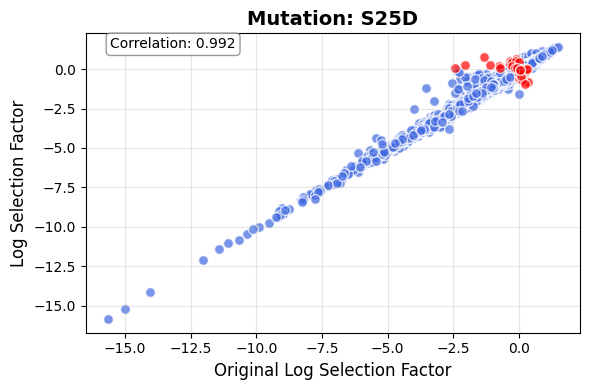

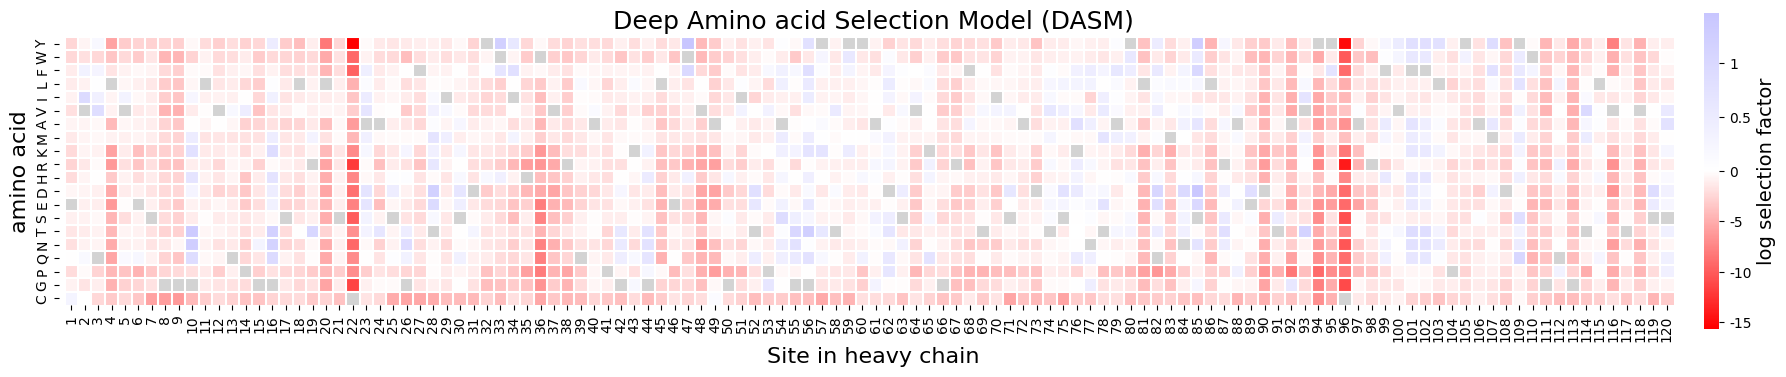

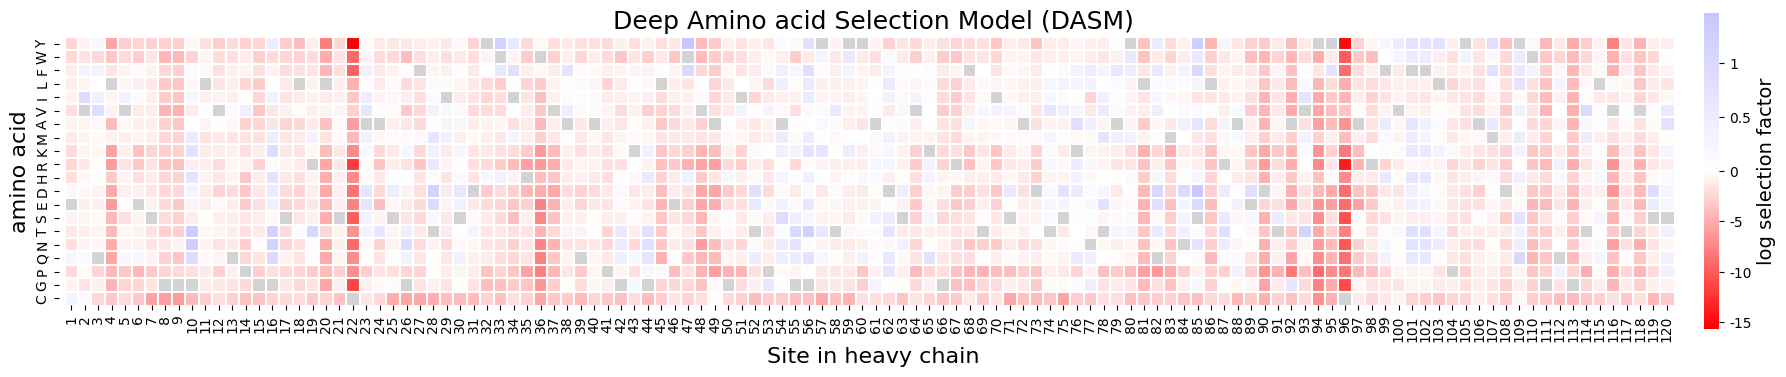

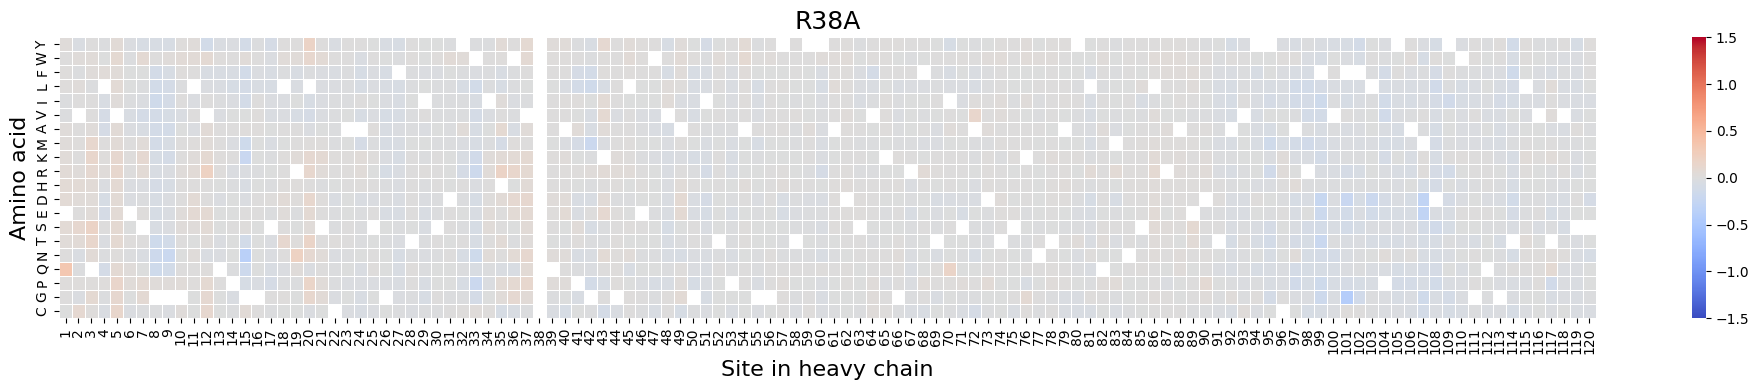

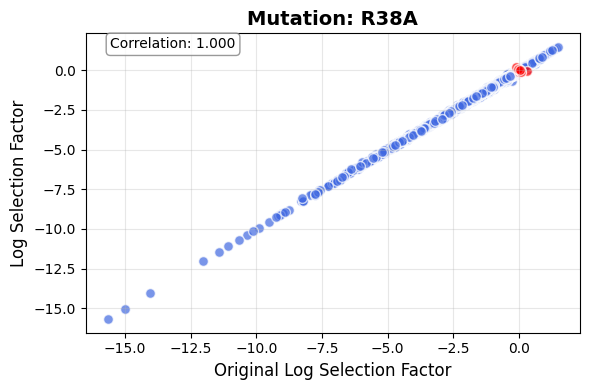

In [20]:
## how does the data look?


for mut in ['S25A', 'S25C', 'S25D', 'R38A']:
    plot_log_heatmap_epistasis(all_data, mut, 'log_selection_factor_diff', title=mut, original_seq=heavy_wt)
    plot_scatter_epistasis(all_data, mut)




## general exploration of distributions - is there correlation between log selection factors and prediction diff?
### yes - although not as pronounced as mc dropout..
### Still, we need to figure out how to normalize this/look at this differently so that we can make inferences of epistasis on it:
### - sign flip (diversifying to puryifying and opposite) - only true/false per pair, and then can aggregate.
### - use mc dropout to generate a confidence interval - get true/falst pre pair and then aggregate.

In [35]:
all_data[all_data.Position == 1]

,AminoAcid,Position,log_selection_factor,mut_from_origin,log_selection_factor_original,log_selection_factor_diff,log_selection_factor_diff_abs,log_selection_factor_ratio,div_pur_flip
206,C,1,0.111776,E1A,0.481044,-0.369268,0.369268,0.369268,False
421,D,1,-0.522297,E1A,-0.606513,0.084216,0.084216,-0.084216,False
634,E,1,1.192476,E1A,NaN,NaN,NaN,NaN,False
849,F,1,-0.402893,E1A,-0.696271,0.293378,0.293378,-0.293378,False
1062,G,1,-0.174751,E1A,-0.319988,0.145236,0.145236,-0.145236,False
...,...,...,...,...,...,...,...,...,...
18390990,S,1,0.175609,C220Y,-0.062893,0.238502,0.238502,-0.238502,True
18391175,T,1,-0.503651,C220Y,-0.775638,0.271987,0.271987,-0.271987,False
18391377,V,1,-1.532731,C220Y,-1.637659,0.104928,0.104928,-0.104928,False
18391575,W,1,-1.237432,C220Y,-1.440989,0.203557,0.203557,-0.203557,False


In [41]:
all_data['log_selection_factor_ratio'] =  all_data.log_selection_factor / all_data.log_selection_factor_original 


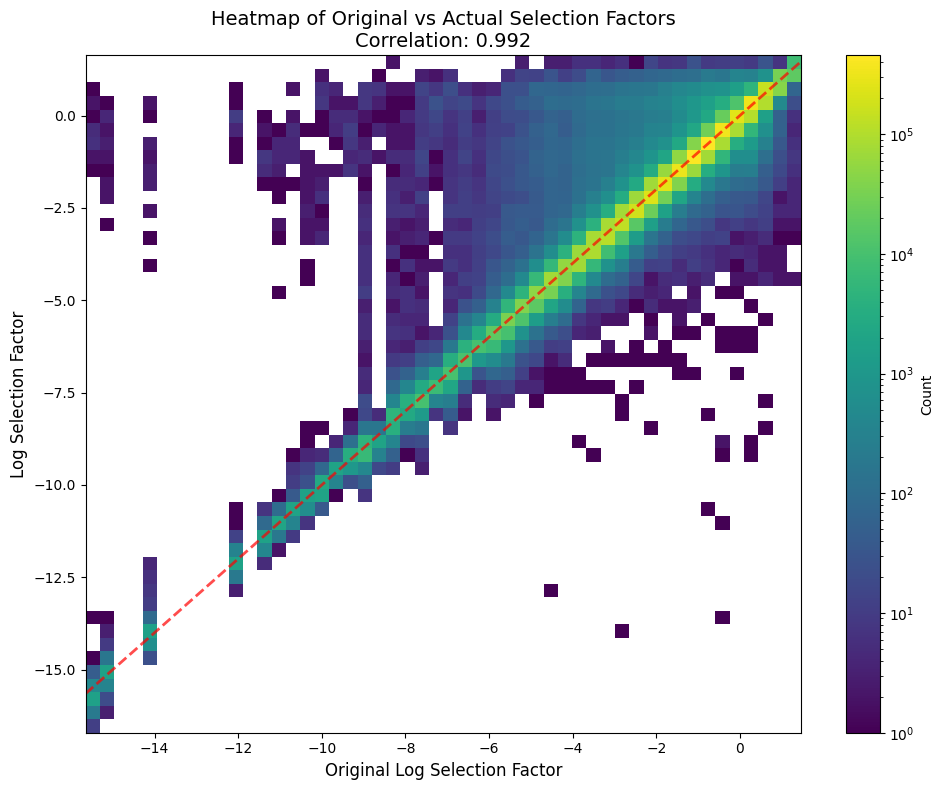

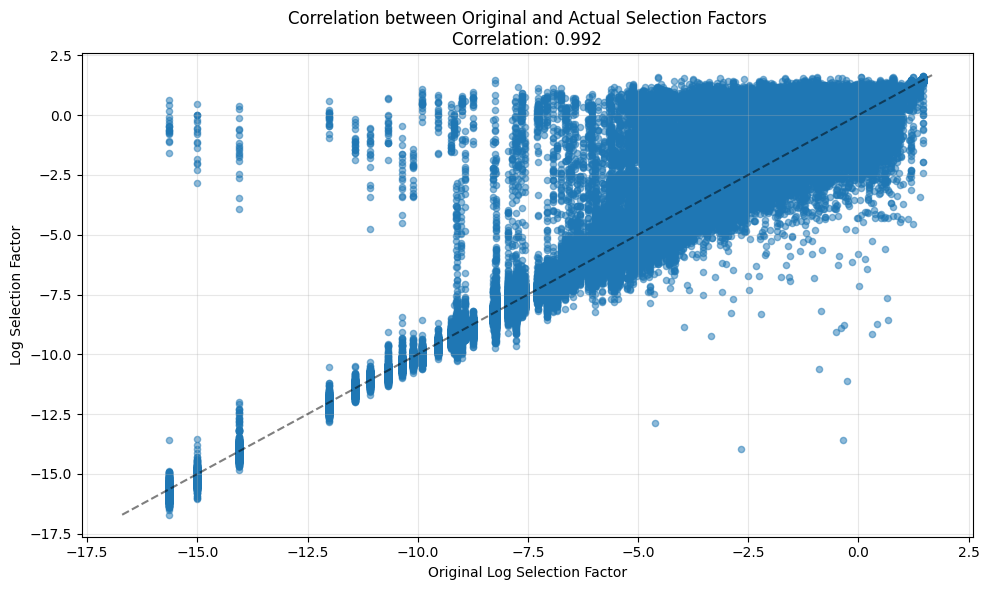

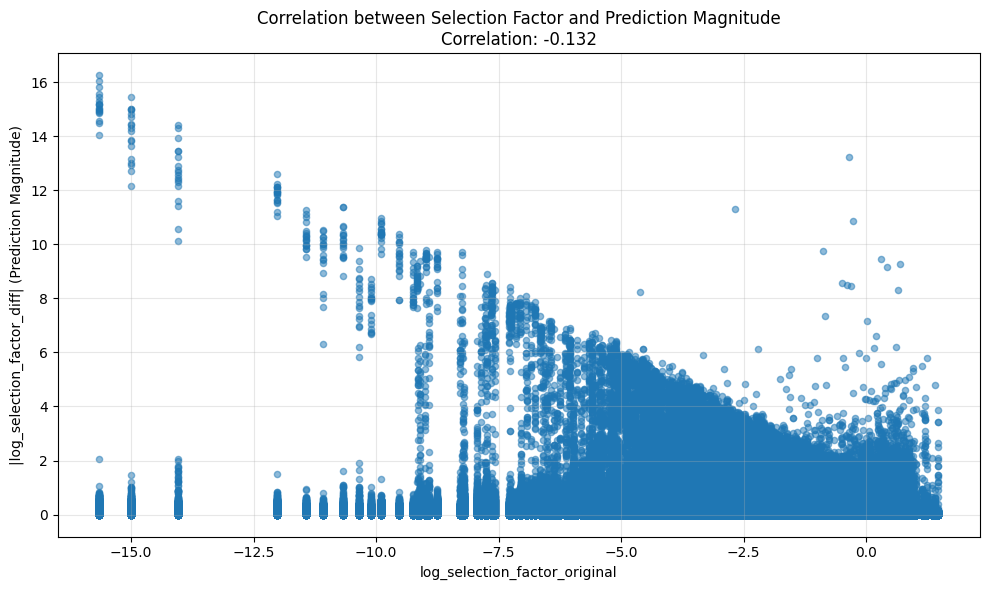

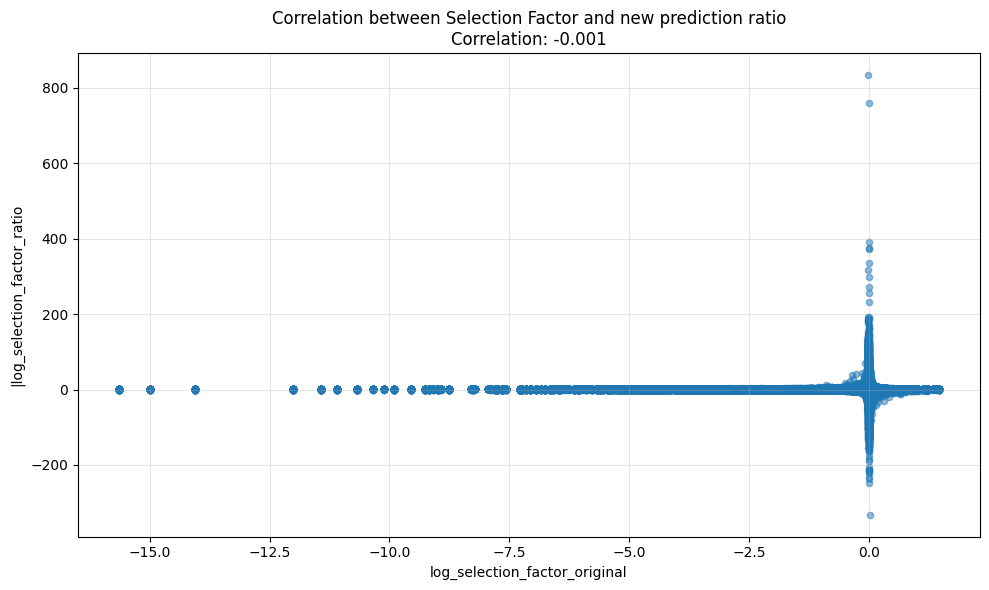

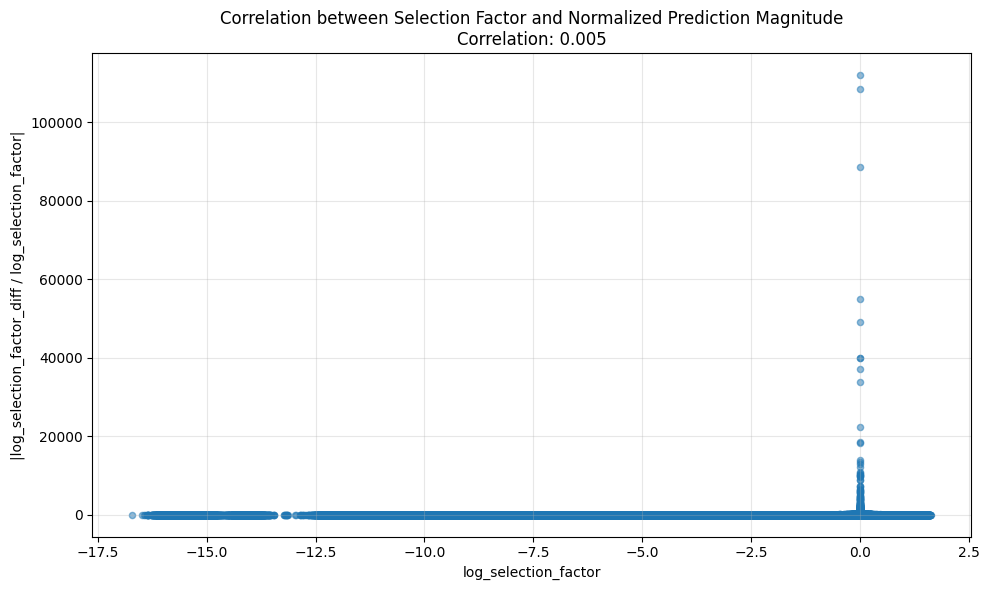

In [43]:

def plot_selection_factor_correlation(data):
    # Create a scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add identity line (y=x)
    min_val = min(data['log_selection_factor_original'].min(), data['log_selection_factor'].min())
    max_val = max(data['log_selection_factor_original'].max(), data['log_selection_factor'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    # Add labels and title
    plt.xlabel('Original Log Selection Factor')
    plt.ylabel('Log Selection Factor')
    plt.title(f'Correlation between Original and Actual Selection Factors\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_selection_factor_heatmap(data):
    # Filter out NaN values
    mask = ~(np.isnan(data['log_selection_factor_original']) | np.isnan(data['log_selection_factor']))
    filtered_data = data.loc[mask]
    
    # Create a 2D histogram (binned data)
    plt.figure(figsize=(10, 8))
    
    # Define the number of bins or bin edges
    bins = 50  # Adjust this number based on your data density
    
    # Create the heatmap using plt.hist2d
    h = plt.hist2d(filtered_data['log_selection_factor_original'], 
                  filtered_data['log_selection_factor'],
                  bins=bins, 
                  cmap='viridis',
                  norm=plt.cm.colors.LogNorm())  # Use log normalization for better visualization
    
    # Add a colorbar
    plt.colorbar(h[3], label='Count')
    
    # Add identity line (y=x)
    min_val = min(filtered_data['log_selection_factor_original'].min(), filtered_data['log_selection_factor'].min())
    max_val = max(filtered_data['log_selection_factor_original'].max(), filtered_data['log_selection_factor'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7)
    
    # Calculate correlation
    corr = filtered_data['log_selection_factor_original'].corr(filtered_data['log_selection_factor'])
    
    # Add labels and title
    plt.xlabel('Original Log Selection Factor', fontsize=12)
    plt.ylabel('Log Selection Factor', fontsize=12)
    plt.title(f'Heatmap of Original vs Actual Selection Factors\nCorrelation: {corr:.3f}', fontsize=14)
    plt.grid(False)  # Grid not needed with heatmap
    
    plt.tight_layout()
    plt.show()

plot_selection_factor_heatmap(all_data)
plot_selection_factor_correlation(all_data)

def plot_simple_correlation(data):
    # Calculate the absolute value of the difference (prediction magnitude)
    data['log_selection_factor_diff_abs'] = data['log_selection_factor_diff'].abs()
    
    # Create a simple scatter plot with axes switched
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor_diff_abs'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_diff_abs']) | np.isnan(data['log_selection_factor_original']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title (switched)
    plt.xlabel('log_selection_factor_original')
    plt.ylabel('|log_selection_factor_diff| (Prediction Magnitude)')
    plt.title(f'Correlation between Selection Factor and Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
plot_simple_correlation(all_data)

def plot_simple_correlation2(data):
    # Calculate the absolute value of the difference (prediction magnitude)
    
    # Create a simple scatter plot with axes switched
    plt.figure(figsize=(10, 6))
    plt.scatter(data['log_selection_factor_original'], data['log_selection_factor_ratio'], 
                alpha=0.5, s=20)
    
    # Calculate correlation (only if there are valid, non-NaN values)
    mask = ~(np.isnan(data['log_selection_factor_ratio']) | np.isnan(data['log_selection_factor_original']))
    if mask.any():
        corr = np.corrcoef(data.loc[mask, 'log_selection_factor_original'], 
                          data.loc[mask, 'log_selection_factor_ratio'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title (switched)
    plt.xlabel('log_selection_factor_original')
    plt.ylabel('|log_selection_factor_ratio')
    plt.title(f'Correlation between Selection Factor and new prediction ratio\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_simple_correlation2(all_data)


def plot_normalized_correlation(data):
    # Create a copy of the data to avoid modifying the original
    plot_data = data.copy()
    
    # Filter out zeros in log_selection_factor to avoid division by zero
    # Also filter out NaN values
    mask = (plot_data['log_selection_factor'] != 0) & ~plot_data['log_selection_factor'].isna() & ~plot_data['log_selection_factor_diff'].isna()
    plot_data = plot_data[mask]
    
    # Calculate normalized difference
    plot_data['normalized_diff'] = plot_data['log_selection_factor_diff'] / plot_data['log_selection_factor']
    
    # Take absolute value for magnitude
    plot_data['normalized_diff_abs'] = plot_data['normalized_diff'].abs()
    
    # Create a simple scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_data['log_selection_factor'], plot_data['normalized_diff_abs'], 
                alpha=0.5, s=20)
    
    # Calculate correlation
    if len(plot_data) > 1:  # Need at least 2 points for correlation
        corr = np.corrcoef(plot_data['log_selection_factor'], 
                          plot_data['normalized_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title
    plt.xlabel('log_selection_factor')
    plt.ylabel('|log_selection_factor_diff / log_selection_factor|')
    plt.title(f'Correlation between Selection Factor and Normalized Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_data  # Return the processed data for further analysis if needed
plot_normalized_correlation(all_data)

def plot_normalized_correlation(data):
    # Create a copy of the data to avoid modifying the original
    plot_data = data.copy()
    
    # Filter out zeros in log_selection_factor to avoid division by zero
    # Also filter out NaN values
    mask = (plot_data['log_selection_factor'] != 0) & ~plot_data['log_selection_factor'].isna() & ~plot_data['log_selection_factor_diff'].isna()
    plot_data = plot_data[mask]
    
    # Calculate normalized difference
    plot_data['normalized_diff'] = plot_data['log_selection_factor_diff'] / plot_data['log_selection_factor']
    
    # Take absolute value for magnitude
    plot_data['normalized_diff_abs'] = plot_data['normalized_diff'].abs()
    
    # Filter out any zero or negative values for log scale
    plot_data = plot_data[plot_data['normalized_diff_abs'] > 0]
    
    # Create a simple scatter plot with log y-axis
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_data['log_selection_factor'], plot_data['normalized_diff_abs'], 
                alpha=0.5, s=20)
    
    # Set y-axis to logarithmic scale
    plt.yscale('log')
    
    # Calculate correlation
    if len(plot_data) > 1:  # Need at least 2 points for correlation
        corr = np.corrcoef(plot_data['log_selection_factor'], 
                          plot_data['normalized_diff_abs'])[0, 1]
        corr_text = f'Correlation: {corr:.3f}'
    else:
        corr_text = 'Cannot calculate correlation (insufficient data)'
    
    # Add labels and title
    plt.xlabel('log_selection_factor')
    plt.ylabel('|log_selection_factor_diff / log_selection_factor| (log scale)')
    plt.title(f'Correlation between Selection Factor and Normalized Prediction Magnitude\n{corr_text}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_data  # Return the processed data for further analysis if needed

In [22]:
### some more measurements


all_data.groupby('div_pur_flip').size()


div_pur_flip
False    5367712
True      104288
dtype: int64

In [23]:
##### to do - add light chain to this as well

## Philips and shculz datasets

In [90]:
#### test out philips dataset
philips_seq = 'EVQLVQSGAEVKKPGASVKVSCKASGYTFTDYHINWVRQAPGQGLEWMGWIHPNSGDTNYAQKFQGWVTMTRDTSISTAYMEVNGLKSDDTAVYYCARGGLEPRSVDYYYYGMDVWGQGTTVTVSS'

if not os.path.exists("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/philips.csv"):
    all_data = run_model_mutating_seq(philips_seq, device='cuda')
    all_data.to_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/philips.csv", index=False)

all_data = pd.read_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/philips.csv")



/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


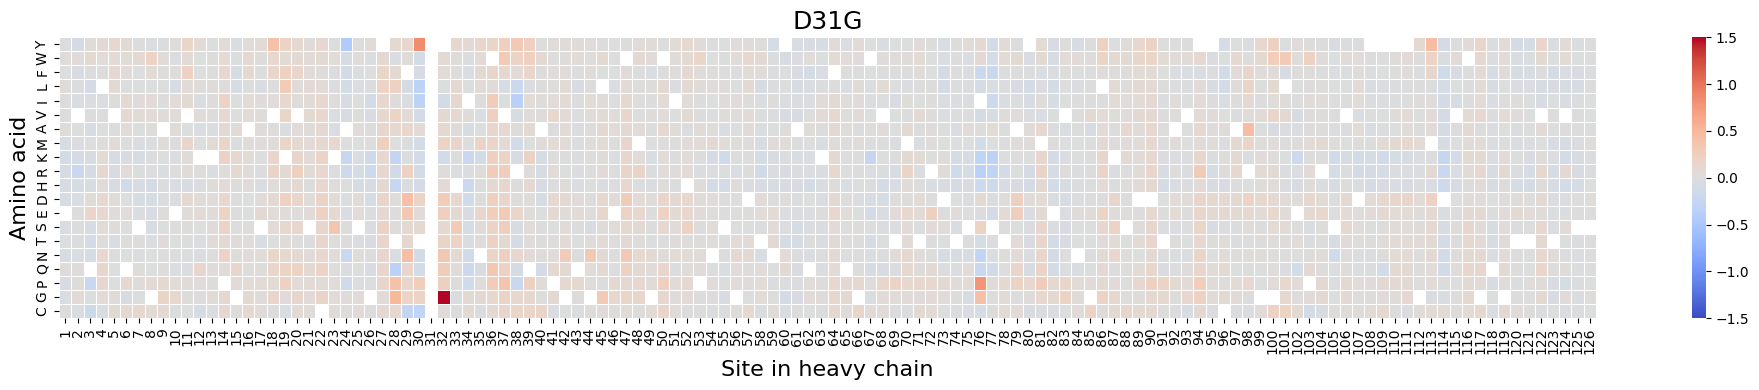

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
1449004        32         G              0.390687   
1450676        30         Y              0.036948   
1449001        28         G              0.117584   
1448459        98         A              0.107808   
1449043        76         G              0.278937   
1449847        28         P              0.084632   
1449968        28         Q             -0.239229   
1449241        30         I             -0.194439   
1449741        44         N              0.038527   
1449483        30         L             -0.272623   
1450212        33         S              0.036061   
1450623       101         W              0.232684   
1450231        52         S              0.187903   
1449369        39         K              0.208708   
1450625       103         W              0.050802   
1448927        77         F             -0.086989   
1448984         9         G              0.026722   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


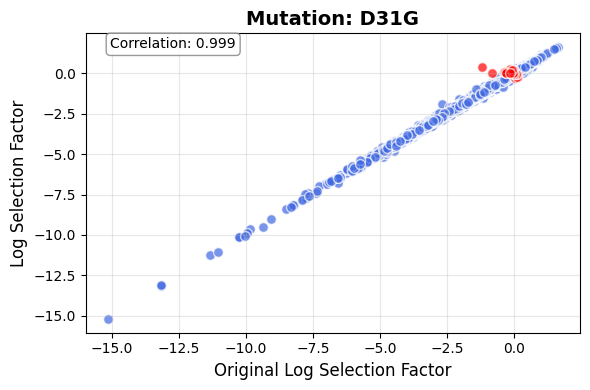

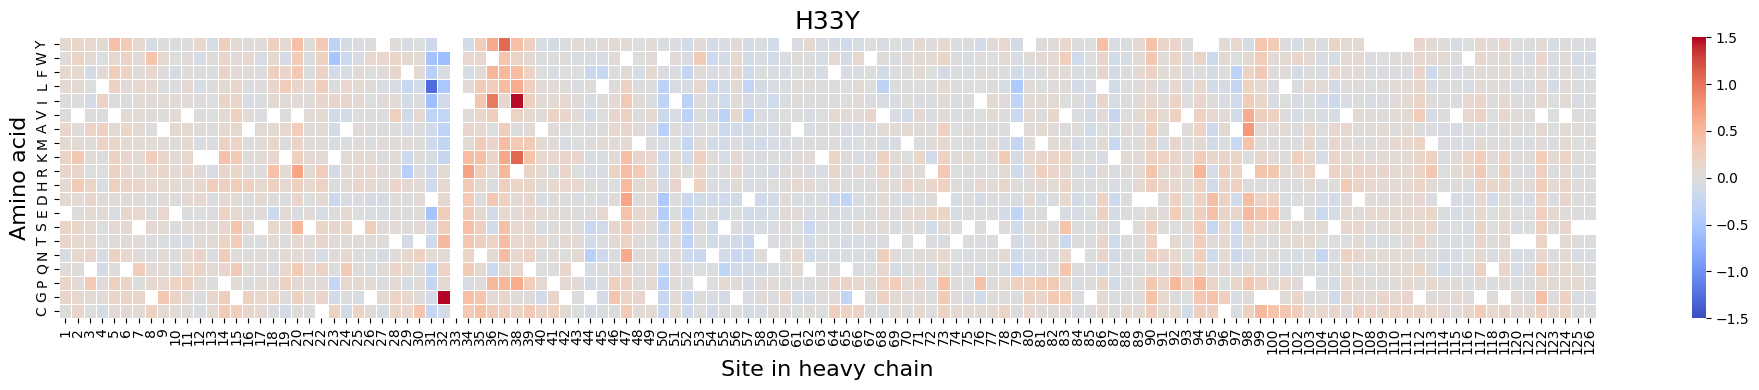

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
1578280        32         G              0.300436   
1578525        38         I              0.319727   
1578761        31         L             -0.989795   
1577735        98         A              0.392144   
1579835        32         W             -0.152024   
1579834        31         W             -0.239442   
1578035        31         E             -0.459405   
1578162        36         F              0.028982   
1578163        37         F              0.148404   
1578646        39         K              0.390625   
1579536        83         S              0.197736   
1579296        83         Q              0.093175   
1578613         2         K              0.207759   
1578259         9         G              0.187914   
1578224        99         F              0.009258   
1578537        50         I             -0.099506   
1579270        55         Q             -0.071643   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


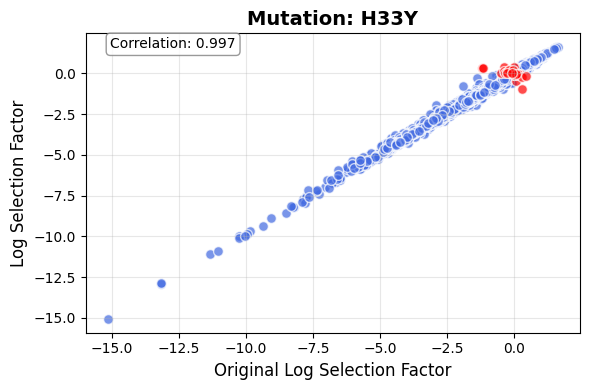

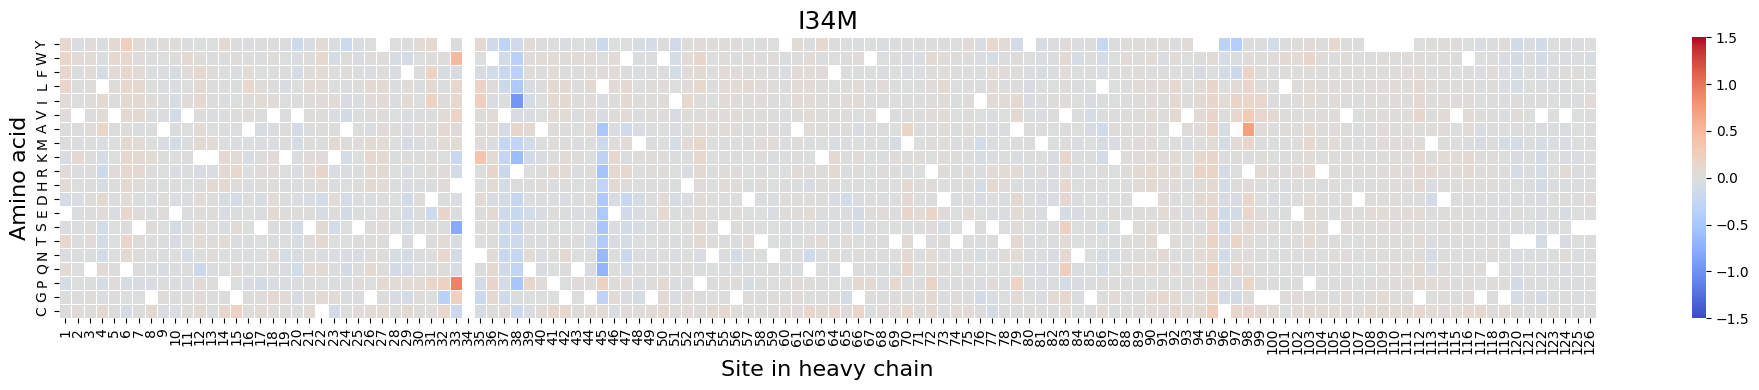

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
1604069        98         A              0.351643   
1605869        83         S              0.043159   
1604557        98         F              0.080913   
1604369        31         E             -0.094460   
1606113        99         V              0.074060   
1605260        76         M             -0.083252   
1606233       101         W              0.011547   
1605538       112         P              0.019543   
1604495        35         F             -0.029497   
1605860        72         S              0.014443   
1606041        23         V             -0.033808   
1604885        65         I              0.017675   
1605666       121         Q             -0.000743   
1604572       113         F              0.005911   

         log_selection_factor_original  
1604069                      -0.350619  
1605869                      -0.165745  
1604557                      -0.100

/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


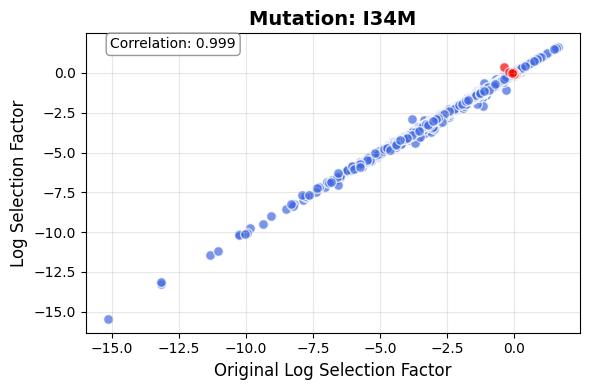

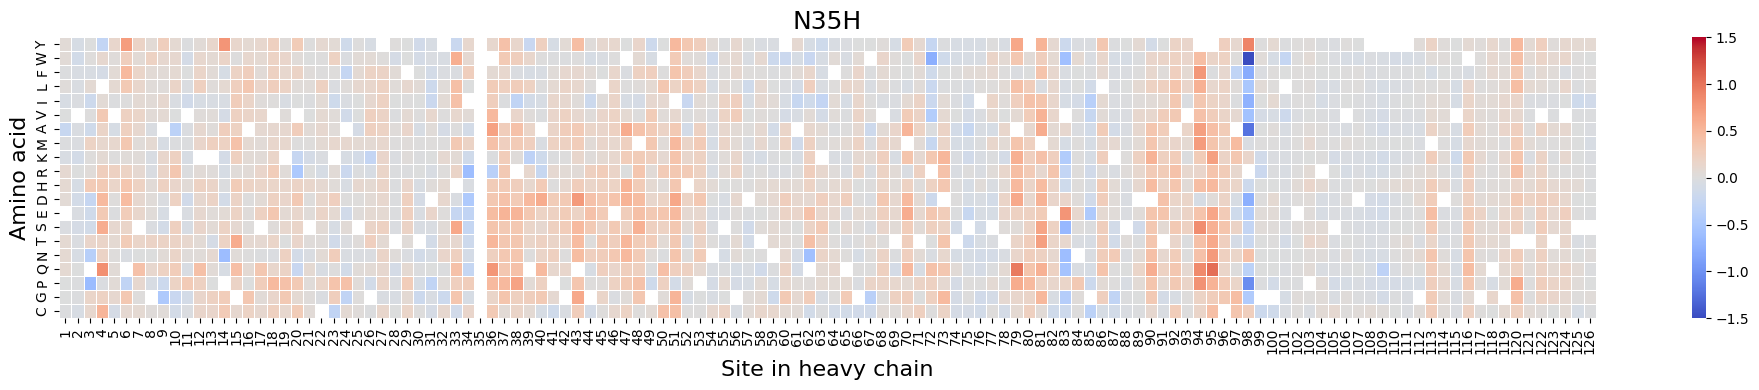

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
1644534        98         W             -2.553293   
1644508        72         W             -0.619808   
1644126        33         S              0.356210   
1643625        14         N             -0.380190   
1643692        83         N             -0.363703   
1644519        83         W             -0.491414   
1643671        62         N             -0.330365   
1643539        51         M              0.287597   
1642725        85         E             -0.343239   
1643444        79         L              0.271141   
1643866        12         Q              0.374663   
1643922        72         Q              0.137048   
1642703        62         E              0.226010   
1644280        73         T              0.062366   
1643206        85         I             -0.095891   
1642948        67         G             -0.181943   
1643959       109         Q             -0.239444   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


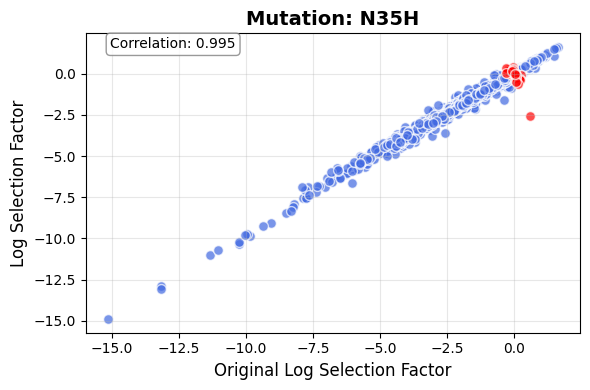

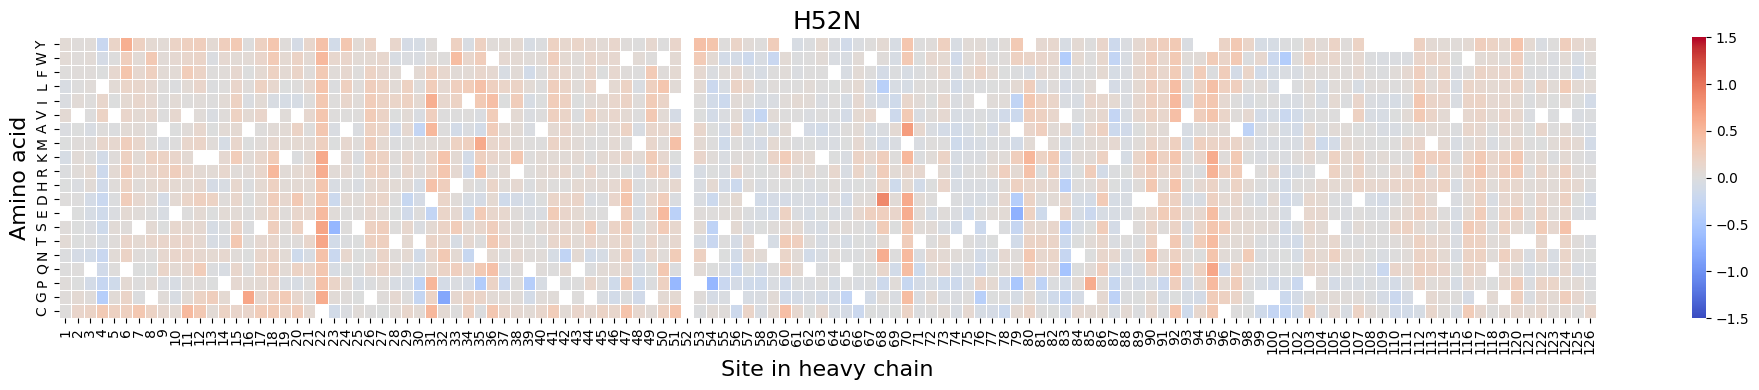

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
2469456        35         M              0.128455   
2469746        85         P              0.002072   
2469087        31         I              0.187539   
2468241        31         A              0.203311   
2469471        51         M              0.217271   
2470449        83         W             -0.321406   
2469013        83         H             -0.236339   
2469819        35         Q              0.265002   
2470420        53         W              0.046028   
2468603        31         E             -0.206971   
2470453        87         W             -0.109504   
2469796        12         Q              0.230802   
2468504        50         D              0.199183   
2469988        85         R              0.042266   
2470426        59         W             -0.129650   
2469889       109         Q             -0.112639   
2469351        54         L             -0.047883   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


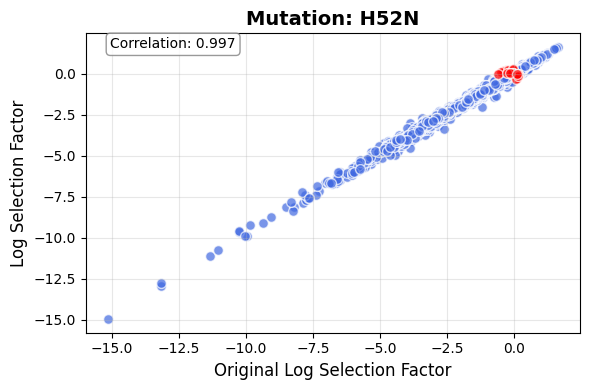

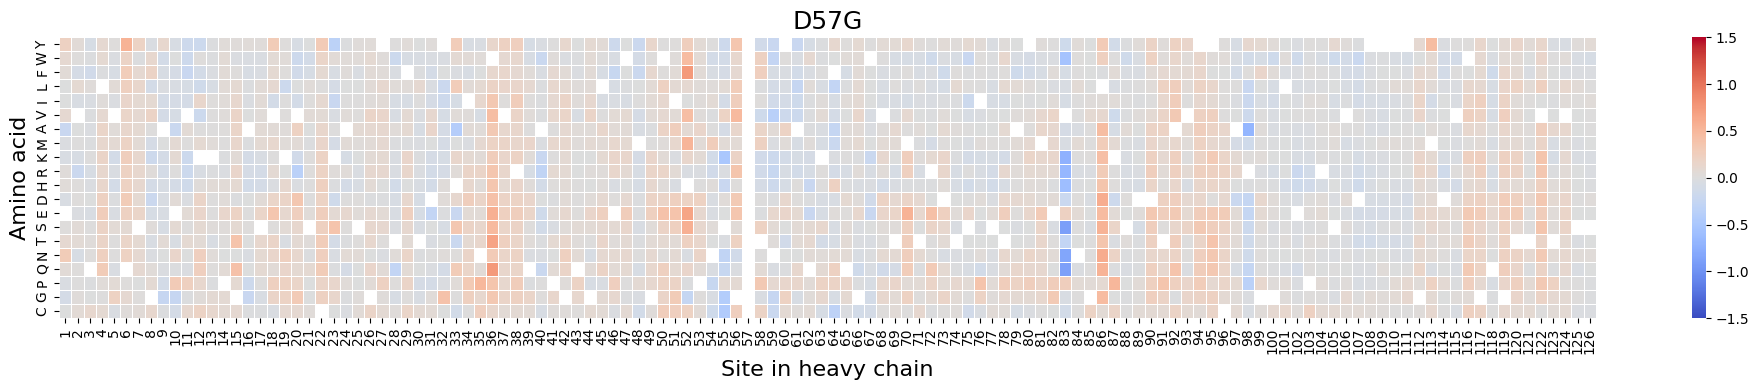

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
2694658        83         N             -0.593204   
2693783        52         F              0.295402   
2695022        83         R             -0.316922   
2693660        52         E              0.126610   
2694048        83         H             -0.485264   
2695111        52         S              0.535416   
2695485        83         W             -0.452066   
2695346        59         V             -0.270932   
2695092        33         S              0.061852   
2694888        72         Q              0.038411   
2695254        83         T             -0.133007   
2694848        28         Q             -0.166239   
2693640        31         E             -0.203922   
2695462        59         W             -0.184712   
2694832        12         Q              0.195679   
2694873        55         Q             -0.000062   
2693923        76         G              0.052004   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


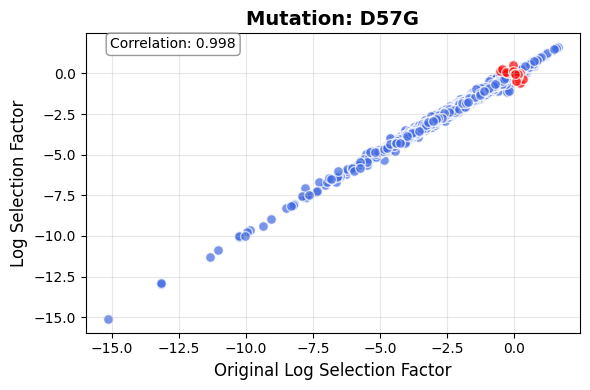

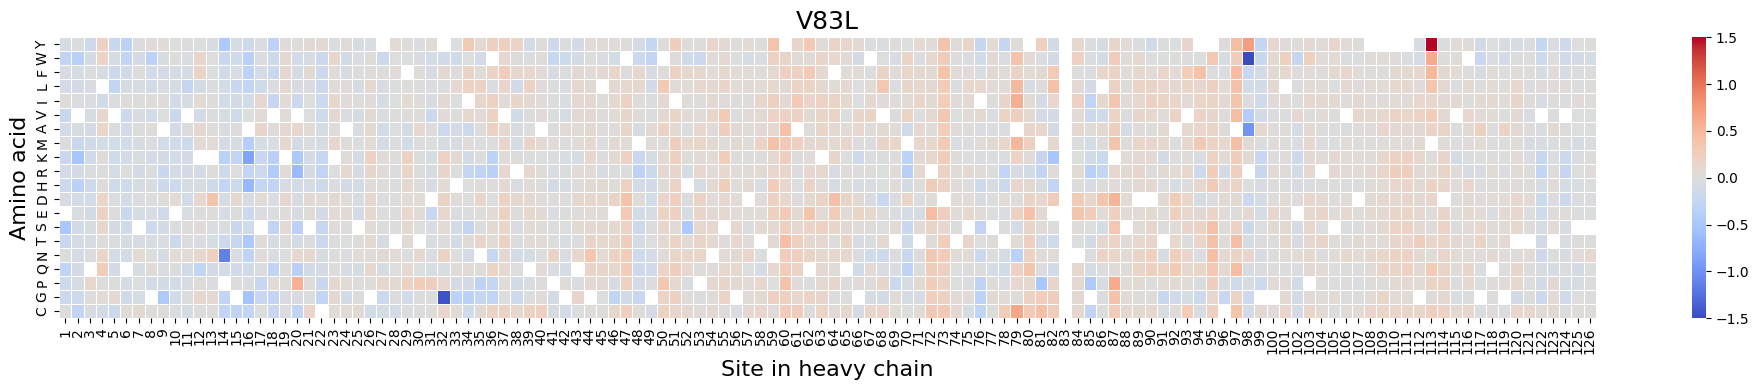

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
3950086       113         Y              0.508766   
3949956        98         W             -0.958809   
3949047        14         N             -0.895383   
3948684        16         K             -0.581244   
3948623        79         I              0.313138   
3948031        87         D              0.293100   
3949519         1         S             -0.294669   
3948298       113         F              0.492991   
3948867        79         L              0.338363   
3949649        16         T             -0.191054   
3949690        60         T              0.015343   
3948969        59         M              0.133297   
3948927        16         M             -0.244806   
3948146        84         E              0.261999   
3949878        16         W             -0.226493   
3948125        62         E              0.207383   
3949076        44         N              0.076445   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


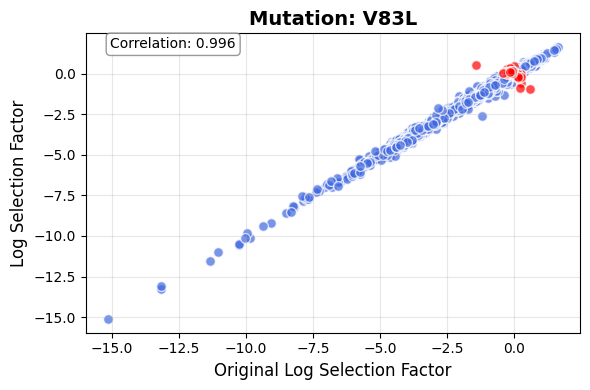

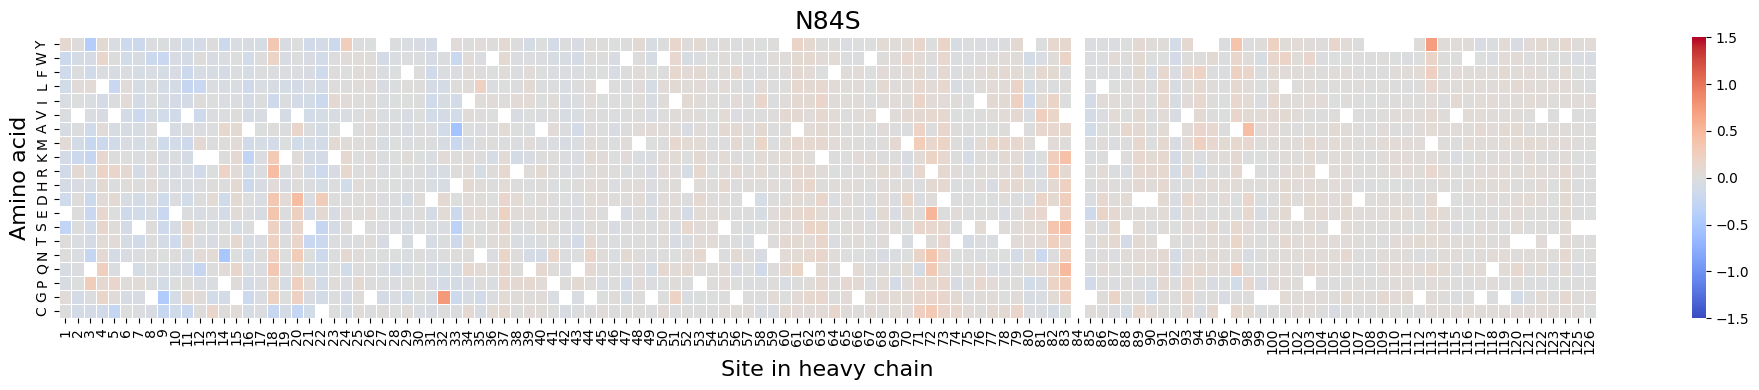

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
4009979        33         A             -0.098668   
4011292        14         N             -0.266512   
4011600        83         Q              0.209027   
4011840        83         S              0.277458   
4010039        98         A              0.087810   
4010992        83         K              0.237465   
4011347        72         N              0.147906   
4011589        72         Q              0.069099   
4010928        16         K             -0.018662   
4011765         1         S             -0.067694   
4011044        11         L             -0.079939   
4010542       113         F              0.236383   
4011227        73         M              0.020296   
4012203       101         W              0.102987   
4011111        79         L              0.018981   
4011822        63         S              0.129775   
4010391        85         E             -0.048130   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


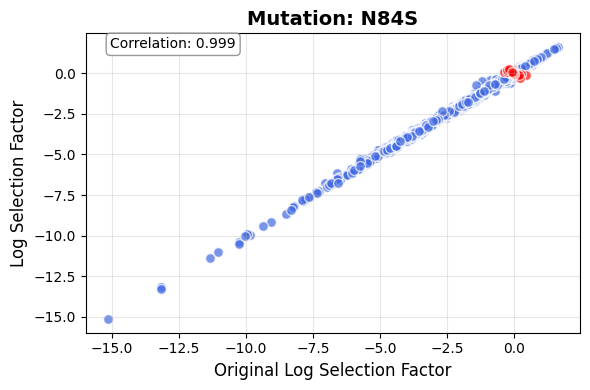

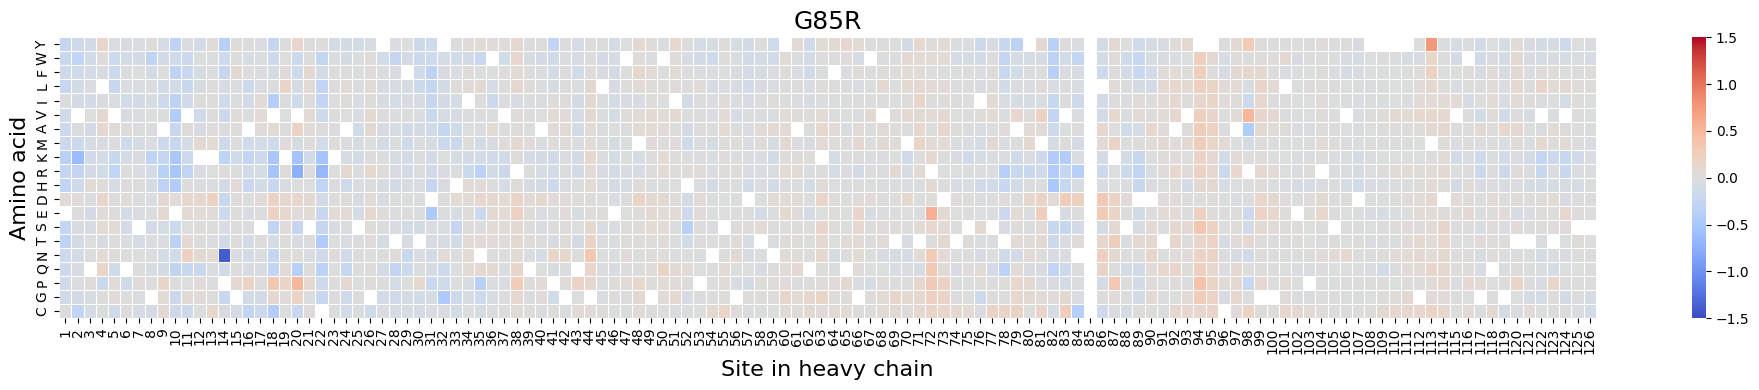

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
4056779        14         N             -1.160939   
4055825        31         E             -0.392952   
4057210        84         R             -0.130164   
4057075        72         Q              0.095684   
4056808        44         N              0.062234   
4056834        72         N              0.087469   
4056415        16         K             -0.002218   
4055555         2         C             -0.131878   
4057035        28         Q             -0.151730   
4057250         1         S             -0.046409   
4056235        83         H             -0.106462   
4056522         1         L             -0.195188   
4055758        84         D              0.196647   
4056028       113         F              0.220550   
4056531        11         L             -0.044845   
4056550        30         L             -0.135017   
4056063        24         G             -0.060789   


/var/folders/0g/rmb4yhl56ws1wyfp85l3_p3m0000gn/T/ipykernel_1018/1857466636.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cur_data = pd.concat([cur_data, cur_data_np], ignore_index=True)


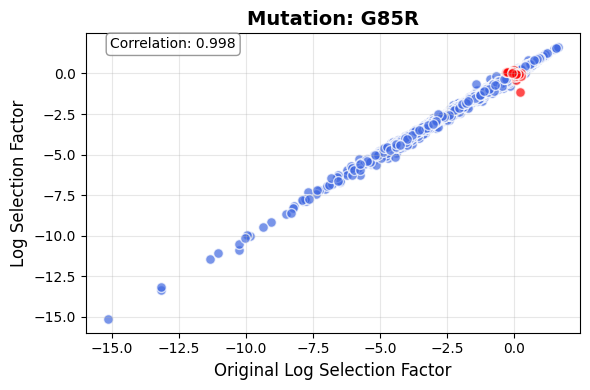

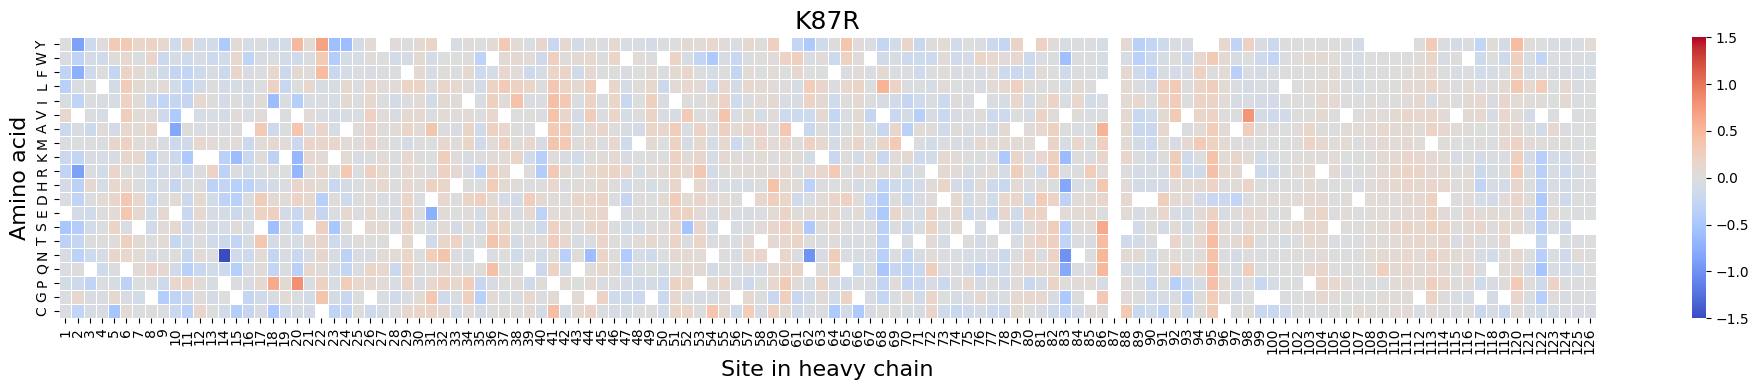

Positions showing a flip in selection factor:
         Position AminoAcid  log_selection_factor  \
4152539        14         N             -1.280835   
4152584        62         N             -0.754177   
4152605        83         N             -0.744117   
4151204        10         A             -0.220706   
4151994        83         H             -0.704761   
4153328        98         V              0.092607   
4151585        31         E             -0.679994   
4152055        18         I             -0.185264   
4153431        83         W             -0.500522   
4152347        68         L              0.390890   
4153010         1         S             -0.293098   
4153066        62         S             -0.249114   
4151970        59         H              0.098936   
4151223        31         A              0.079690   
4152282         1         L             -0.340512   
4153200        83         T             -0.159905   
4153368        16         W             -0.153863   


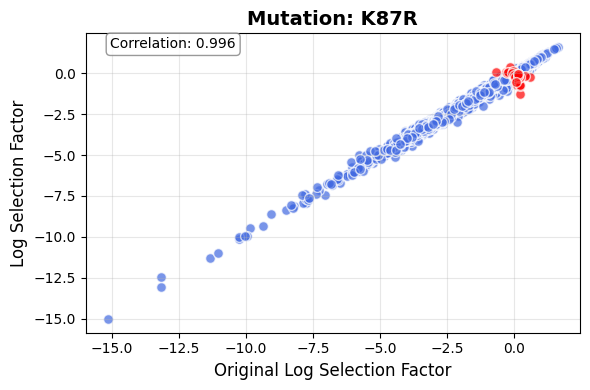

In [23]:
for mut in ['D31G', 'H33Y', 'I34M', 'N35H','H52N', 'D57G', 'V83L', 'N84S', 'G85R', 'K87R']:
    # mutations from the philips paper
    plot_log_heatmap_epistasis(all_data, mut, 'log_selection_factor_diff', title=mut)
    plot_scatter_epistasis(all_data, mut)
    print_epistatics_measurement_summary(all_data, mut)



In [79]:
##  schulz data
schulz = 'EVQLVESGGGLIQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLEWVSVIYSGGSTFYADSVKGRFTISRDNSKNTLYLQMNSLRAEDTAVYYCARDLGTGLFDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSC'


if not os.path.exists("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/schulz.csv"):
    all_data = run_model_mutating_seq(schulz, device='cuda')
    all_data.to_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/schulz.csv", index=False)
all_data = pd.read_csv("/fh/fast/matsen_e/nharel/epistasis/dasm_mutate_run/schulz.csv")


## aggregate data:
### per position pair
### per position+amino acid mutation and position
### per position+amino acid mutation

In [91]:
all_data['mut_from_origin_start_aa'] = all_data.mut_from_origin.str[0]
all_data['mut_from_origin_end_aa'] = all_data.mut_from_origin.str[-1]
all_data['mut_from_origin_pos'] = all_data.mut_from_origin.str[1:-1].astype(int)
all_data

,AminoAcid,Position,log_selection_factor,mut_from_origin,log_selection_factor_original,log_selection_factor_diff,log_selection_factor_diff_abs,log_selection_factor_ratio,div_pur_flip,mut_from_origin_start_aa,mut_from_origin_end_aa,mut_from_origin_pos
0,A,2,0.134817,E1A,0.357011,-0.222194,0.222194,0.222194,False,E,A,1
1,A,3,-1.027918,E1A,-1.001896,-0.026023,0.026023,0.026023,False,E,A,1
2,A,4,-3.534567,E1A,-3.595201,0.060634,0.060634,-0.060634,False,E,A,1
3,A,5,-0.747792,E1A,-0.453405,-0.294388,0.294388,0.294388,False,E,A,1
4,A,6,-4.273507,E1A,-3.818023,-0.455483,0.455483,0.455483,False,E,A,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6032875,Y,121,-1.259503,S126Y,-1.264837,0.005334,0.005334,-0.005334,False,S,Y,126
6032876,Y,122,-4.621936,S126Y,-3.972170,-0.649767,0.649767,0.649767,False,S,Y,126
6032877,Y,123,-1.288267,S126Y,-1.258387,-0.029880,0.029880,0.029880,False,S,Y,126
6032878,Y,124,-4.626138,S126Y,-4.242200,-0.383938,0.383938,0.383938,False,S,Y,126


In [92]:
## aggregate by position pairs

(array([  0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,   8.5,
          9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,  17.5,
         18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,  26.5,
         27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,  34.5,  35.5,
         36.5,  37.5,  38.5,  39.5,  40.5,  41.5,  42.5,  43.5,  44.5,
         45.5,  46.5,  47.5,  48.5,  49.5,  50.5,  51.5,  52.5,  53.5,
         54.5,  55.5,  56.5,  57.5,  58.5,  59.5,  60.5,  61.5,  62.5,
         63.5,  64.5,  65.5,  66.5,  67.5,  68.5,  69.5,  70.5,  71.5,
         72.5,  73.5,  74.5,  75.5,  76.5,  77.5,  78.5,  79.5,  80.5,
         81.5,  82.5,  83.5,  84.5,  85.5,  86.5,  87.5,  88.5,  89.5,
         90.5,  91.5,  92.5,  93.5,  94.5,  95.5,  96.5,  97.5,  98.5,
         99.5, 100.5, 101.5, 102.5, 103.5, 104.5, 105.5, 106.5, 107.5,
        108.5, 109.5, 110.5, 111.5, 112.5, 113.5, 114.5, 115.5, 116.5,
        117.5, 118.5, 119.5, 120.5, 121.5, 122.5, 123.5, 124.5, 125.5]),
 [Te

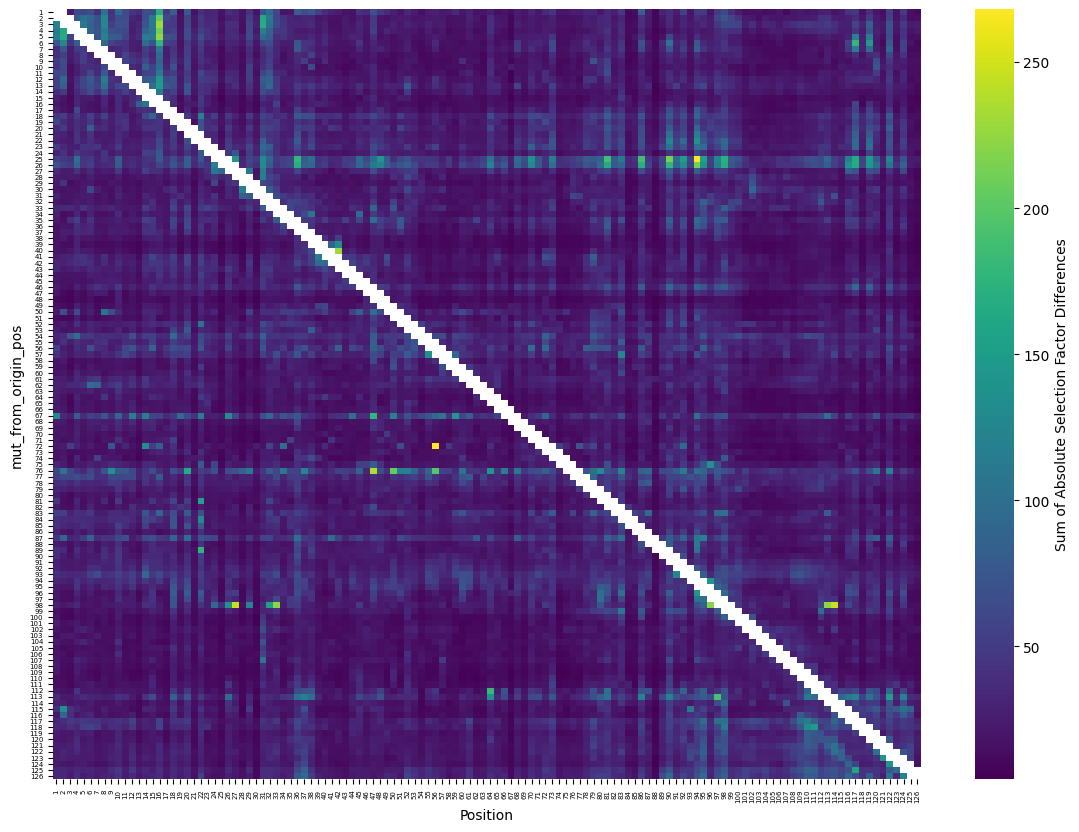

In [93]:
df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_pos', 'Position']).log_selection_factor_diff_abs.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_pos", columns="Position", values="log_selection_factor_diff_abs")

# Plot the heatmap
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Selection Factor Differences'})

# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller



(array([  0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,   8.5,
          9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,  17.5,
         18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,  26.5,
         27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,  34.5,  35.5,
         36.5,  37.5,  38.5,  39.5,  40.5,  41.5,  42.5,  43.5,  44.5,
         45.5,  46.5,  47.5,  48.5,  49.5,  50.5,  51.5,  52.5,  53.5,
         54.5,  55.5,  56.5,  57.5,  58.5,  59.5,  60.5,  61.5,  62.5,
         63.5,  64.5,  65.5,  66.5,  67.5,  68.5,  69.5,  70.5,  71.5,
         72.5,  73.5,  74.5,  75.5,  76.5,  77.5,  78.5,  79.5,  80.5,
         81.5,  82.5,  83.5,  84.5,  85.5,  86.5,  87.5,  88.5,  89.5,
         90.5,  91.5,  92.5,  93.5,  94.5,  95.5,  96.5,  97.5,  98.5,
         99.5, 100.5, 101.5, 102.5, 103.5, 104.5, 105.5, 106.5, 107.5,
        108.5, 109.5, 110.5, 111.5, 112.5, 113.5, 114.5, 115.5, 116.5,
        117.5, 118.5, 119.5, 120.5, 121.5, 122.5, 123.5, 124.5, 125.5]),
 [Te

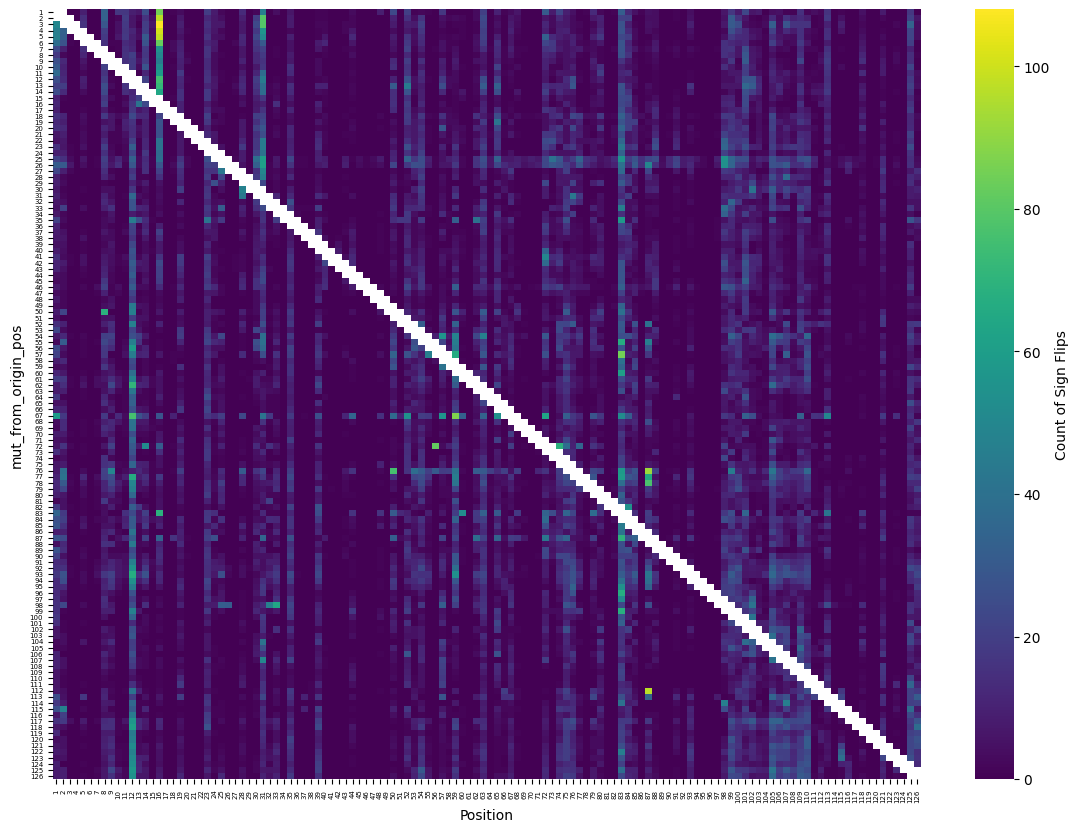

In [94]:
df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_pos', 'Position']).div_pur_flip.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_pos", columns="Position", values="div_pur_flip")

# Plot the heatmap
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Count of Sign Flips'})
# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller



(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'A'),
  Text(0, 1.5, 'C'),
  Text(0, 2.5, 'D'),
  Text(0, 3.5, 'E'),
  Text(0, 4.5, 'F'),
  Text(0, 5.5, 'G'),
  Text(0, 6.5, 'H'),
  Text(0, 7.5, 'I'),
  Text(0, 8.5, 'K'),
  Text(0, 9.5, 'L'),
  Text(0, 10.5, 'M'),
  Text(0, 11.5, 'N'),
  Text(0, 12.5, 'P'),
  Text(0, 13.5, 'Q'),
  Text(0, 14.5, 'R'),
  Text(0, 15.5, 'S'),
  Text(0, 16.5, 'T'),
  Text(0, 17.5, 'V'),
  Text(0, 18.5, 'W'),
  Text(0, 19.5, 'Y')])

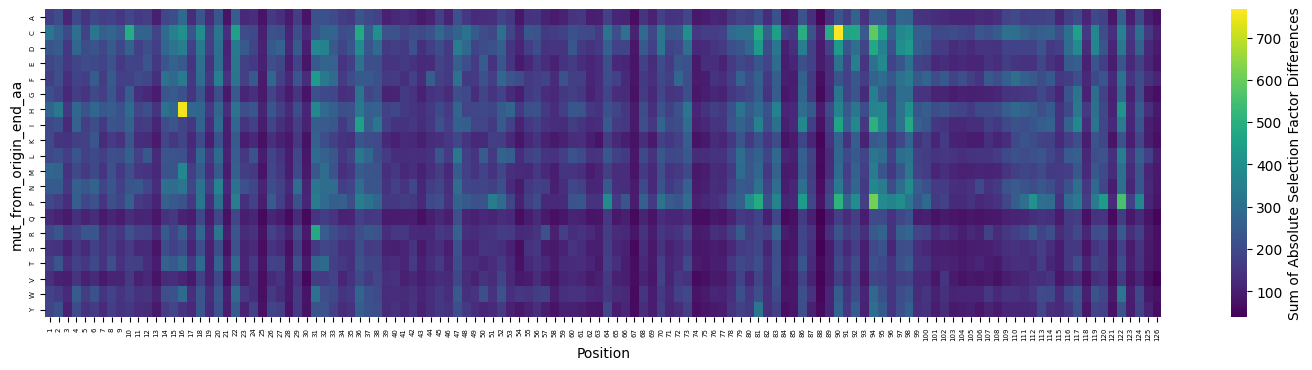

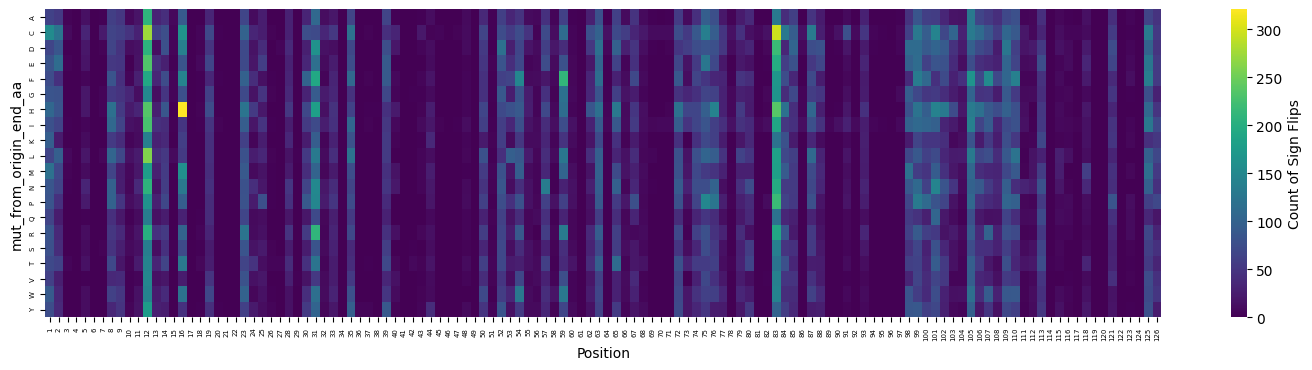

In [95]:
df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_end_aa', 'Position']).log_selection_factor_diff_abs.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_end_aa", columns="Position", values="log_selection_factor_diff_abs")

# Plot the heatmap
plt.figure(figsize=(18,4))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Selection Factor Differences'})
# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller

df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_end_aa', 'Position']).div_pur_flip.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_end_aa", columns="Position", values="div_pur_flip")

# Plot the heatmap
plt.figure(figsize=(18,4))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Count of Sign Flips'})
# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller




(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'A'),
  Text(0, 1.5, 'C'),
  Text(0, 2.5, 'D'),
  Text(0, 3.5, 'E'),
  Text(0, 4.5, 'F'),
  Text(0, 5.5, 'G'),
  Text(0, 6.5, 'H'),
  Text(0, 7.5, 'I'),
  Text(0, 8.5, 'K'),
  Text(0, 9.5, 'L'),
  Text(0, 10.5, 'M'),
  Text(0, 11.5, 'N'),
  Text(0, 12.5, 'P'),
  Text(0, 13.5, 'Q'),
  Text(0, 14.5, 'R'),
  Text(0, 15.5, 'S'),
  Text(0, 16.5, 'T'),
  Text(0, 17.5, 'V'),
  Text(0, 18.5, 'W'),
  Text(0, 19.5, 'Y')])

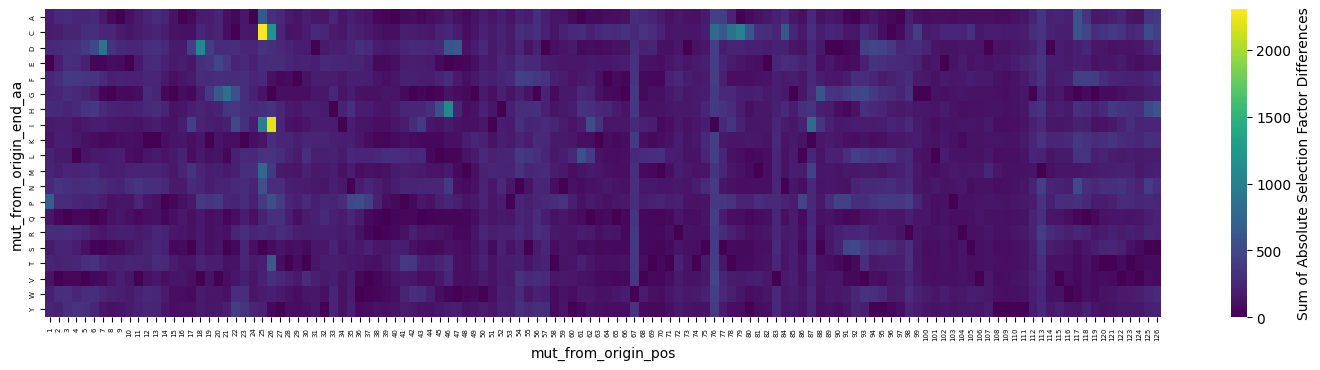

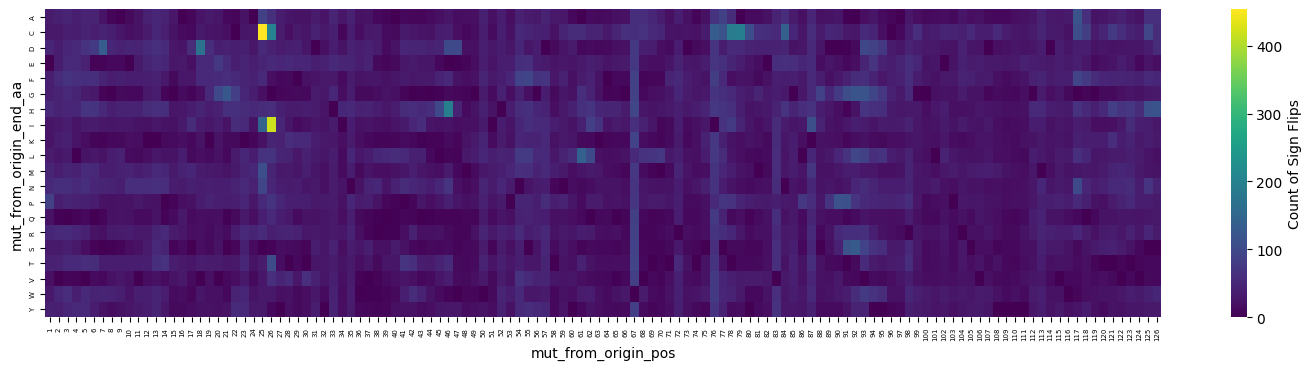

In [99]:
df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_end_aa', 'mut_from_origin_pos']).log_selection_factor_diff_abs.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_end_aa", columns="mut_from_origin_pos", values="log_selection_factor_diff_abs")

# Plot the heatmap
plt.figure(figsize=(18,4))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Sum of Absolute Selection Factor Differences'})
# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller

df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['mut_from_origin_end_aa', 'mut_from_origin_pos']).div_pur_flip.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
pivot_df = df.pivot(index="mut_from_origin_end_aa", columns="mut_from_origin_pos", values="div_pur_flip")

# Plot the heatmap
plt.figure(figsize=(18,4))
heatmap = sns.heatmap(pivot_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True, cbar_kws={'label': 'Count of Sign Flips'})
# Adjust x-axis labels
plt.xticks(rotation=90, fontsize=5)  # Rotate x labels 90 degrees and make them smaller
plt.yticks(fontsize=5)  # Make y labels smaller




([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '

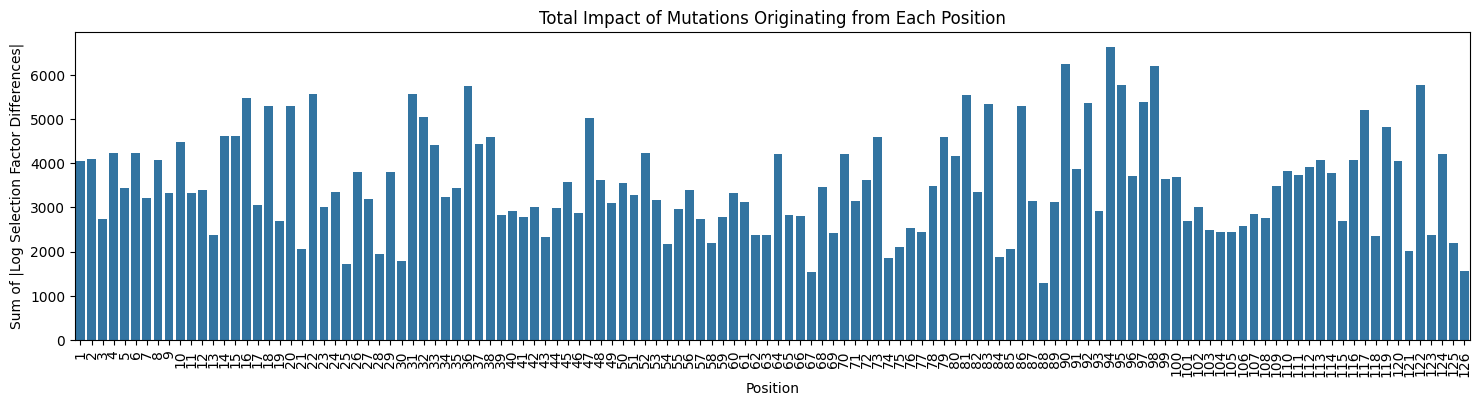

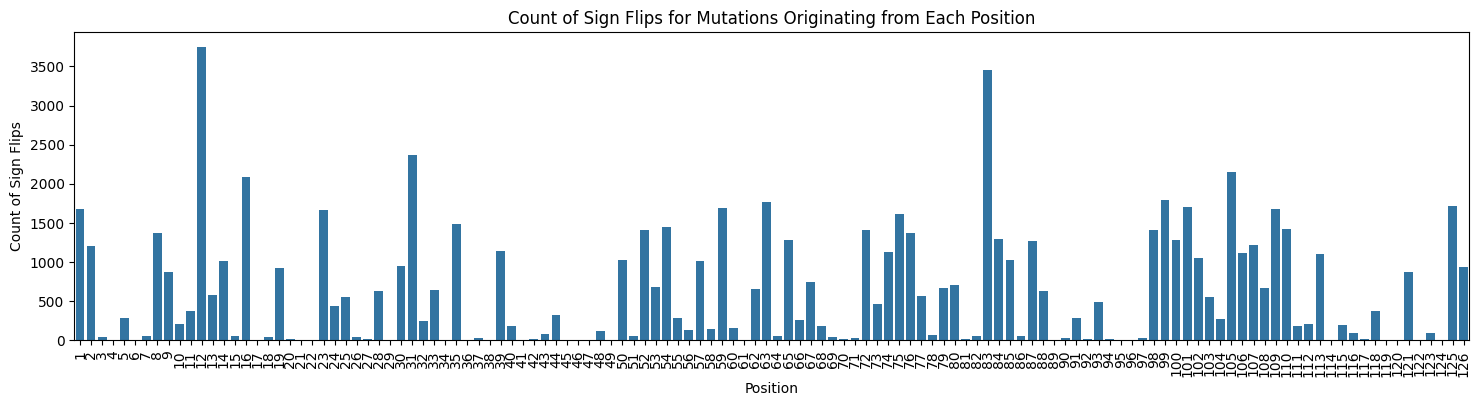

In [98]:
df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['Position']).log_selection_factor_diff_abs.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
# Create a bar plot
plt.figure(figsize=(18, 4))

ax = sns.barplot(x='Position', y='log_selection_factor_diff_abs', data=df)

# Add labels and title
plt.xlabel('Position')
plt.ylabel('Sum of |Log Selection Factor Differences|')
plt.title('Total Impact of Mutations Originating from Each Position')

# Improve readability of x-axis labels
plt.xticks(rotation=90)



df = all_data[(all_data.mut_from_origin_pos != all_data.Position) & ((all_data.mut_from_origin_pos - all_data.Position).abs() > 1)].groupby(['Position']).div_pur_flip.sum().reset_index()
# Pivot the data to create a matrix suitable for a heatmap
# Create a bar plot
plt.figure(figsize=(18, 4))

ax = sns.barplot(x='Position', y='div_pur_flip', data=df)

# Add labels and title
plt.xlabel('Position')
plt.ylabel('Count of Sign Flips')
plt.title('Count of Sign Flips for Mutations Originating from Each Position')

# Improve readability of x-axis labels
plt.xticks(rotation=90)
